
## Exploring and pre-processing a dataset

    

#### Objectives

* Explore the dataset
* Pre-process dataset as required (may be for visualization)


## Introduction

In this notebook, I pre-processed and anlysed the datasets before applying data visualization techniques on it.

------------


## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">

1. [Exploring Datasets](#0)<br>
2. [Dataset: Immigration to Canada from 1980 to 2013](#1)<br>
3. [*pandas* Basics](#2) <br>
4. [Indexing and Selection](#3) <br>
5. [Filtering based on a criteria](#4)<br>
6. [Sorting Values](#5)
7. [Author](#author)

</div>


### Exploring Dataset  <a id="0"></a>

*pandas* is a Python package providing fast, flexible, and expressive data structures designed to make working with “relational” or “labeled” data both easy and intuitive. It aims to be the fundamental high-level building block for doing practical, **real world** data analysis in Python.

### Dataset: Immigration to Canada from 1980 to 2013 <a id="1"></a>


Dataset Source: [International migration flows to and from selected countries - The 2015 revision](https://www.un.org/development/desa/pd/data/international-migration-flows).

The dataset contains annual data on the flows of international immigrants as recorded by the countries of destination. The data presents both inflows and outflows according to the place of birth, citizenship or place of previous / next residence both for foreigners and nationals. The current version presents data pertaining to 45 countries.

In this notebook, I focused on the Canadian immigration data.

![Data Preview](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/Module%201/images/DataSnapshot.png)

 The Canada Immigration dataset can be fetched from <a href="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.xlsx">here</a>.

---


### Basics<a id="2"></a>


Installing **openpyxl** (formerly **xlrd**), a module that *pandas* requires to read Excel files.


In [6]:
%pip install -qqq openpyxl
%pip install -qqq matplotlib
%pip install -qqq pandas
%pip install -qqq seaborn
%pip install -qqq numpy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Importing our primary Canadian Immigration dataset using *pandas*'s `read_excel()` method.

In [8]:
df_can = pd.read_excel(
    'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.xlsx',
    sheet_name='Canada by Citizenship',
    skiprows=range(20),
    skipfooter=2)

df_can.head()

,Type,Coverage,OdName,AREA,AreaName,REG,RegName,DEV,DevName,1980,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Immigrants,Foreigners,Afghanistan,935,Asia,5501,Southern Asia,902,Developing regions,16,...,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004
1,Immigrants,Foreigners,Albania,908,Europe,925,Southern Europe,901,Developed regions,1,...,1450,1223,856,702,560,716,561,539,620,603
2,Immigrants,Foreigners,Algeria,903,Africa,912,Northern Africa,902,Developing regions,80,...,3616,3626,4807,3623,4005,5393,4752,4325,3774,4331
3,Immigrants,Foreigners,American Samoa,909,Oceania,957,Polynesia,902,Developing regions,0,...,0,0,1,0,0,0,0,0,0,0
4,Immigrants,Foreigners,Andorra,908,Europe,925,Southern Europe,901,Developed regions,0,...,0,0,1,1,0,0,0,0,1,1


In [9]:
df_can.tail()

,Type,Coverage,OdName,AREA,AreaName,REG,RegName,DEV,DevName,1980,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
190,Immigrants,Foreigners,Viet Nam,935,Asia,920,South-Eastern Asia,902,Developing regions,1191,...,1816,1852,3153,2574,1784,2171,1942,1723,1731,2112
191,Immigrants,Foreigners,Western Sahara,903,Africa,912,Northern Africa,902,Developing regions,0,...,0,0,1,0,0,0,0,0,0,0
192,Immigrants,Foreigners,Yemen,935,Asia,922,Western Asia,902,Developing regions,1,...,124,161,140,122,133,128,211,160,174,217
193,Immigrants,Foreigners,Zambia,903,Africa,910,Eastern Africa,902,Developing regions,11,...,56,91,77,71,64,60,102,69,46,59
194,Immigrants,Foreigners,Zimbabwe,903,Africa,910,Eastern Africa,902,Developing regions,72,...,1450,615,454,663,611,508,494,434,437,407


Geting a short summary of the dataframe.


In [10]:
df_can.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Columns: 43 entries, Type to 2013
dtypes: int64(37), object(6)
memory usage: 65.6+ KB


In [11]:
df_can.columns

Index([    'Type', 'Coverage',   'OdName',     'AREA', 'AreaName',      'REG',
        'RegName',      'DEV',  'DevName',       1980,       1981,       1982,
             1983,       1984,       1985,       1986,       1987,       1988,
             1989,       1990,       1991,       1992,       1993,       1994,
             1995,       1996,       1997,       1998,       1999,       2000,
             2001,       2002,       2003,       2004,       2005,       2006,
             2007,       2008,       2009,       2010,       2011,       2012,
             2013],
      dtype='object')

Similarly, using the `.index` instance variables.


In [12]:
df_can.index

RangeIndex(start=0, stop=195, step=1)

In [13]:
print(type(df_can.columns))
print(type(df_can.index))

<class 'pandas.core.indexes.base.Index'>
<class 'pandas.core.indexes.range.RangeIndex'>


To get the index and columns as lists, using the `tolist()` method.


In [14]:
df_can.columns.tolist()

['Type',
 'Coverage',
 'OdName',
 'AREA',
 'AreaName',
 'REG',
 'RegName',
 'DEV',
 'DevName',
 1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013]

In [15]:
df_can.index.tolist()

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [16]:
print(type(df_can.columns.tolist()))
print(type(df_can.index.tolist()))

<class 'list'>
<class 'list'>


To view the dimensions of the dataframe, using the `shape` instance variable of it.


In [17]:
df_can.shape

(195, 43)

**Note**: The main types stored in *pandas* objects are `float`, `int`, `bool`, `datetime64[ns]`, `datetime64[ns, tz]`, `timedelta[ns]`, `category`, and `object` (string). In addition, these dtypes have item sizes, e.g. `int64` and `int32`.


Cleaning the data set to remove a few unnecessary columns. Using *pandas* `drop()` method:

In [18]:
df_can.drop(['AREA','REG','DEV','Type','Coverage'], axis=1, inplace=True)
df_can.head(2)

,OdName,AreaName,RegName,DevName,1980,1981,1982,1983,1984,1985,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,...,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,...,1450,1223,856,702,560,716,561,539,620,603


Renaming the columns so that they make sense. Using `rename()` method by passing in a dictionary of old and new names:

In [19]:
df_can.rename(columns={'OdName':'Country', 'AreaName':'Continent', 'RegName':'Region'}, inplace=True)
df_can.columns

Index([  'Country', 'Continent',    'Region',   'DevName',        1980,
              1981,        1982,        1983,        1984,        1985,
              1986,        1987,        1988,        1989,        1990,
              1991,        1992,        1993,        1994,        1995,
              1996,        1997,        1998,        1999,        2000,
              2001,        2002,        2003,        2004,        2005,
              2006,        2007,        2008,        2009,        2010,
              2011,        2012,        2013],
      dtype='object')

Adding a 'Total' column that sums up the total immigrants by country over the entire period 1980 - 2013:

In [20]:
# Ensure columns are strings and exist
years= list(map(int, range(1980, 2014)))
df_can['Total'] = df_can[years].sum(axis=1)
df_can['Total']

0      58639
1      15699
2      69439
3          6
4         15
       ...  
190    97146
191        2
192     2985
193     1677
194     8598
Name: Total, Length: 195, dtype: int64

Checking null objects in the datasets:


In [21]:
df_can.isnull().sum()

Country      0
Continent    0
Region       0
DevName      0
1980         0
1981         0
1982         0
1983         0
1984         0
1985         0
1986         0
1987         0
1988         0
1989         0
1990         0
1991         0
1992         0
1993         0
1994         0
1995         0
1996         0
1997         0
1998         0
1999         0
2000         0
2001         0
2002         0
2003         0
2004         0
2005         0
2006         0
2007         0
2008         0
2009         0
2010         0
2011         0
2012         0
2013         0
Total        0
dtype: int64

Finally, a quick summary of each column in the dataframe using the `describe()` method.

In [22]:
df_can.describe()

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,508.394872,566.989744,534.723077,387.435897,376.497436,358.861538,441.271795,691.133333,714.389744,843.241026,...,1320.292308,1266.958974,1191.820513,1246.394872,1275.733333,1420.287179,1262.533333,1313.958974,1320.702564,32867.451282
std,1949.588546,2152.643752,1866.997511,1204.333597,1198.246371,1079.309600,1225.576630,2109.205607,2443.606788,2555.048874,...,4425.957828,3926.717747,3443.542409,3694.573544,3829.630424,4462.946328,4030.084313,4247.555161,4237.951988,91785.498686
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,1.000000,1.000000,...,28.500000,25.000000,31.000000,31.000000,36.000000,40.500000,37.500000,42.500000,45.000000,952.000000
50%,13.000000,10.000000,11.000000,12.000000,13.000000,17.000000,18.000000,26.000000,34.000000,44.000000,...,210.000000,218.000000,198.000000,205.000000,214.000000,211.000000,179.000000,233.000000,213.000000,5018.000000
75%,251.500000,295.500000,275.000000,173.000000,181.000000,197.000000,254.000000,434.000000,409.000000,508.500000,...,832.000000,842.000000,899.000000,934.500000,888.000000,932.000000,772.000000,783.000000,796.000000,22239.500000
max,22045.000000,24796.000000,20620.000000,10015.000000,10170.000000,9564.000000,9470.000000,21337.000000,27359.000000,23795.000000,...,42584.000000,33848.000000,28742.000000,30037.000000,29622.000000,38617.000000,36765.000000,34315.000000,34129.000000,691904.000000


---

## Indexing and Selection (slicing) <a id="3"></a>


### Select Column
**There are two ways to filter on a column name:**

Method 1: 
```python
    df.column_name               
```

Method 2:

```python
    df['column']                  
```


In [23]:
df_can.Country  # returns a series

0         Afghanistan
1             Albania
2             Algeria
3      American Samoa
4             Andorra
            ...      
190          Viet Nam
191    Western Sahara
192             Yemen
193            Zambia
194          Zimbabwe
Name: Country, Length: 195, dtype: object

Filtering on the list of countries ('Country') and the data for years: 1980 - 1985.


In [24]:
df_can.loc[:, [1980, 1981, 1982, 1983, 1984, 1985]]  # returns a dataframe

,1980,1981,1982,1983,1984,1985
0,16,39,39,47,71,340
1,1,0,0,0,0,0
2,80,67,71,69,63,44
3,0,1,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
190,1191,1829,2162,3404,7583,5907
191,0,0,0,0,0,0
192,1,2,1,6,0,18
193,11,17,11,7,16,9


### Select Row

There are main 2 ways to select rows:

```python
    df.loc[label]    # filters by the labels of the index/column
    df.iloc[index]   # filters by the positions of the index/column
```


The default index of the dataset is a numeric range from 0 to 194. This makes it very difficult to do a query by a specific country. For example to search for data on Japan, I need to know the corresponding index value.

This can be fixed very easily by setting the 'Country' column as the index using `set_index()` method.


In [25]:
df_can.set_index('Country', inplace=True)

In [26]:
df_can.head(3)

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439


In [27]:
df_can.index.name = None

Let's view the number of immigrants from Japan (row 87) for the following scenarios:
    1. The full row data (all columns)
    2. For year 2013
    3. For years 1980 to 1985


In [28]:
df_can.loc['Japan']

Continent                 Asia
Region            Eastern Asia
DevName      Developed regions
1980                       701
1981                       756
1982                       598
1983                       309
1984                       246
1985                       198
1986                       248
1987                       422
1988                       324
1989                       494
1990                       379
1991                       506
1992                       605
1993                       907
1994                       956
1995                       826
1996                       994
1997                       924
1998                       897
1999                      1083
2000                      1010
2001                      1092
2002                       806
2003                       817
2004                       973
2005                      1067
2006                      1212
2007                      1250
2008                      1284
2009    

In [29]:
df_can.iloc[87]

Continent                 Asia
Region            Eastern Asia
DevName      Developed regions
1980                       701
1981                       756
1982                       598
1983                       309
1984                       246
1985                       198
1986                       248
1987                       422
1988                       324
1989                       494
1990                       379
1991                       506
1992                       605
1993                       907
1994                       956
1995                       826
1996                       994
1997                       924
1998                       897
1999                      1083
2000                      1010
2001                      1092
2002                       806
2003                       817
2004                       973
2005                      1067
2006                      1212
2007                      1250
2008                      1284
2009    

In [30]:
df_can[df_can.index == 'Japan']

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Japan,Asia,Eastern Asia,Developed regions,701,756,598,309,246,198,248,...,1067,1212,1250,1284,1194,1168,1265,1214,982,27707


In [31]:
# for year 2013
df_can.loc['Japan', 2013].item(0)

982

In [32]:
# year 2013 is the last column, with a positional index of 36
df_can.iloc[87, 36].item(0)

982

In [33]:
# for years 1980 to 1985
df_can.loc['Japan', [1980, 1981, 1982, 1983, 1984, 1984]]

1980    701
1981    756
1982    598
1983    309
1984    246
1984    246
Name: Japan, dtype: object

In [34]:
df_can.iloc[87, [3, 4, 5, 6, 7, 8]]

1980    701
1981    756
1982    598
1983    309
1984    246
1985    198
Name: Japan, dtype: object

Let's view the number of immigrants from **Haiti** for the following scenarios: <br>1. The full row data (all columns) <br>2. For year 2000 <br>3. For years 1990 to 1995


In [35]:
print(df_can.loc['Haiti'], "\n")
print(df_can.loc['Haiti', 2000], "\n")
df_can.loc['Haiti', [1990, 1991, 1992, 1993, 1994, 1995]]

Continent    Latin America and the Caribbean
Region                             Caribbean
DevName                   Developing regions
1980                                    1666
1981                                    3692
1982                                    3498
1983                                    2860
1984                                    1418
1985                                    1321
1986                                    1753
1987                                    2132
1988                                    1829
1989                                    2377
1990                                    2379
1991                                    2829
1992                                    2399
1993                                    3655
1994                                    2100
1995                                    2014
1996                                    1955
1997                                    1645
1998                                    1295
1999      

1990    2379
1991    2829
1992    2399
1993    3655
1994    2100
1995    2014
Name: Haiti, dtype: object

Column names that are integers (such as the years) might introduce some confusion. For example, when I am referencing the year 2013, one might confuse that when the 2013th positional index. 

Let's convert the column names into strings: '1980' to '2013'.


In [36]:
df_can.columns = list(map(str, df_can.columns))
# [print (type(x)) for x in df_can.columns.values] #<-- uncomment to check type of column headers

In [37]:
years = list(map(str, range(1980, 2014)))
years

['1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013']

Creating a list named 'year' using map function for years ranging from 1990 to 2013. Then extracting the data series from the dataframe df_can for Haiti using year list. 


In [38]:
year = list(map(str, range(1990, 2014)))
haiti = df_can.loc['Haiti', year]

### Filtering based on a criteria <a id="4"></a>
To filter the dataframe based on a condition, I passed the condition as a boolean vector. 

Filtering the dataframe to show the data on Asian countries (AreaName = Asia).


In [39]:
# reating the condition boolean series
condition = df_can['Continent'] == 'Asia'
print(condition)

Afghanistan        True
Albania           False
Algeria           False
American Samoa    False
Andorra           False
                  ...  
Viet Nam           True
Western Sahara    False
Yemen              True
Zambia            False
Zimbabwe          False
Name: Continent, Length: 195, dtype: bool


In [40]:
# passing this condition into the dataFrame
df_can[condition].head()

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Armenia,Asia,Western Asia,Developing regions,0,0,0,0,0,0,0,...,224,218,198,205,267,252,236,258,207,3310
Azerbaijan,Asia,Western Asia,Developing regions,0,0,0,0,0,0,0,...,359,236,203,125,165,209,138,161,57,2649
Bahrain,Asia,Western Asia,Developing regions,0,2,1,1,1,3,0,...,12,12,22,9,35,28,21,39,32,475
Bangladesh,Asia,Southern Asia,Developing regions,83,84,86,81,98,92,486,...,4171,4014,2897,2939,2104,4721,2694,2640,3789,65568


In [41]:
df_can[(df_can['Continent']=='Asia') & (df_can['Region']=='Southern Asia')]

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Bangladesh,Asia,Southern Asia,Developing regions,83,84,86,81,98,92,486,...,4171,4014,2897,2939,2104,4721,2694,2640,3789,65568
Bhutan,Asia,Southern Asia,Developing regions,0,0,0,0,1,0,0,...,5,10,7,36,865,1464,1879,1075,487,5876
India,Asia,Southern Asia,Developing regions,8880,8670,8147,7338,5704,4211,7150,...,36210,33848,28742,28261,29456,34235,27509,30933,33087,691904
Iran (Islamic Republic of),Asia,Southern Asia,Developing regions,1172,1429,1822,1592,1977,1648,1794,...,5837,7480,6974,6475,6580,7477,7479,7534,11291,175923
Maldives,Asia,Southern Asia,Developing regions,0,0,0,1,0,0,0,...,0,0,2,1,7,4,3,1,1,30
Nepal,Asia,Southern Asia,Developing regions,1,1,6,1,2,4,13,...,607,540,511,581,561,1392,1129,1185,1308,10222
Pakistan,Asia,Southern Asia,Developing regions,978,972,1201,900,668,514,691,...,14314,13127,10124,8994,7217,6811,7468,11227,12603,241600
Sri Lanka,Asia,Southern Asia,Developing regions,185,371,290,197,1086,845,1838,...,4930,4714,4123,4756,4547,4422,3309,3338,2394,148358


Getting the data where AreaName is 'Africa' and RegName is 'Southern Africa'.


In [42]:
df_can[(df_can['Continent'] == 'Africa') & (df_can['Region'] == 'Southern Africa')]

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Botswana,Africa,Southern Africa,Developing regions,10,1,3,3,7,4,2,...,7,11,8,28,15,42,53,64,76,396
Lesotho,Africa,Southern Africa,Developing regions,1,1,1,2,7,5,3,...,4,0,4,1,8,7,1,0,6,107
Namibia,Africa,Southern Africa,Developing regions,0,5,5,3,2,1,1,...,6,19,13,26,14,16,23,24,83,320
South Africa,Africa,Southern Africa,Developing regions,1026,1118,781,379,271,310,718,...,988,1111,1200,1123,1188,1238,959,1243,1240,40568
Swaziland,Africa,Southern Africa,Developing regions,4,1,1,0,10,7,1,...,7,7,5,6,10,3,13,17,39,188


### Sorting Values of a Dataframe or Series <a id="5"></a><br>
Using the `sort_values()` function to sort the DataFrame or a Series based on one or more columns. 

```df.sort_values(col_name, axis=0, ascending=True, inplace=False, ignore_index=False)```<br><br>
col_nam - the column(s) to sort by. <br>
axis - axis along which to sort. 0 for sorting by rows (default) and 1 for sorting by columns.<br>
ascending - to sort in ascending order (True, default) or descending order (False).<br>
inplace - to perform the sorting operation in-place (True) or return a sorted copy (False, default).<br>
ignore_index - to reset the index after sorting (True) or keep the original index values (False, default).<br>


Sorting on 'Total' column, in descending order to find out the top 5 countries that contributed the most to immigration to Canada. 


In [43]:
df_can.sort_values(by='Total', ascending=False, axis=0, inplace=True)
top_5 = df_can['Total'].head(5)
top_5.to_frame()

,Total
India,691904
China,659962
United Kingdom of Great Britain and Northern Ireland,551500
Philippines,511391
Pakistan,241600


Finding out top 3 countries that contributes the most to immigration to Canda in the year 2010.

In [44]:
df_can.sort_values(by='2010', ascending=False, axis=0)["2010"].head(3).to_frame()

,2010
Philippines,38617
India,34235
China,30391


---

# Line Plots 
    
## Objectives

* Create Data Visualization using Line Plots

## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">

1. [Visualizing Data using Matplotlib](#8) <br>
2. [Line Plots](#4)
</div>

## Line Pots (Series/Dataframe) <a id="4"></a>

**What is a line plot and why use it?**

A line plot is a type of plot which displays information as a series of data points called 'markers' connected by straight line segments. It is a basic type of chart common in many fields.




In [45]:
haiti = df_can.loc['Haiti', years] # passing in years 1980 - 2013 to exclude the 'total' column
haiti.head()

1980    1666
1981    3692
1982    3498
1983    2860
1984    1418
Name: Haiti, dtype: object

**Analyzing impact of Earthquake on Haiti**

In 2010, Haiti suffered a catastrophic magnitude 7.0 earthquake. The quake caused widespread devastation and loss of life and about three million people were affected by this natural disaster. As part of Canada's humanitarian effort, the Government of Canada stepped up its effort in accepting refugees from Haiti. I visualized this effort using a `Line` plot:

Ploting a line graph of immigration from Haiti using `df.plot()`.

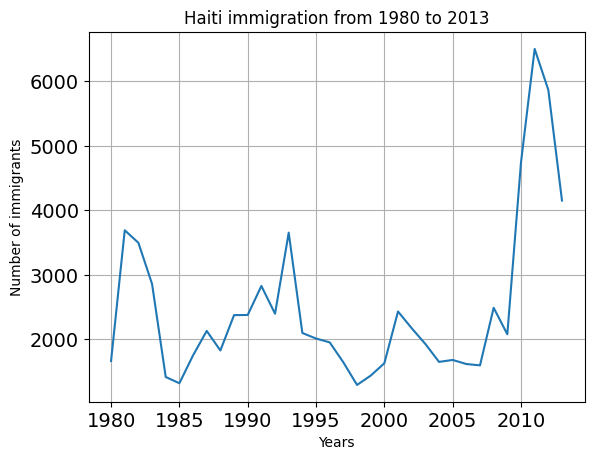

In [46]:
haiti.plot(title='Haiti immigration from 1980 to 2013', fontsize=14, grid=True)
plt.ylabel('Number of immigrants')
plt.xlabel('Years')

plt.show();

Changing the type of the index values to *integer* first

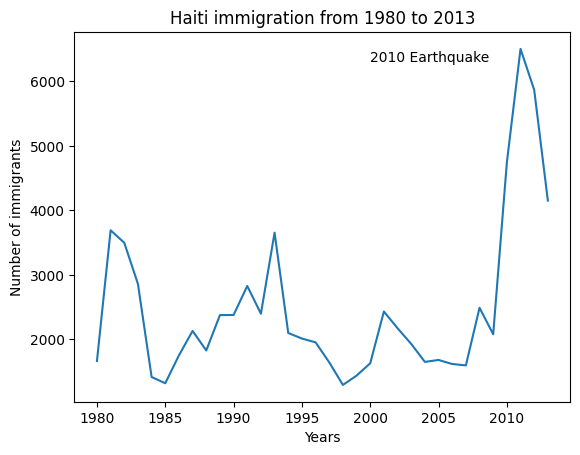

In [47]:
haiti.index = haiti.index.map(int) 
haiti.plot(title='Haiti immigration from 1980 to 2013')
plt.ylabel('Number of immigrants')
plt.xlabel('Years')

# annotating the 2010 Earthquake. 
plt.text(2000, 6300, '2010 Earthquake')

plt.show();

It can be clearly noticed how number of immigrants from Haiti spiked up from 2010 as Canada stepped up its efforts to accept refugees from Haiti. Annotating this spike in the plot by using the `plt.text()` method.<br>

Since the x-axis (years) is type 'integer', I specified x as a year. The y axis (number of immigrants) is type 'integer', so I just specified the value y = 6000.

If the years were stored as type 'string', I would need to specify x as the index position of the year. Eg 20th index is year 2000 since it is the 20th year with a base year of 1980.

Comparing the number of immigrants from India and China from 1980 to 2013.

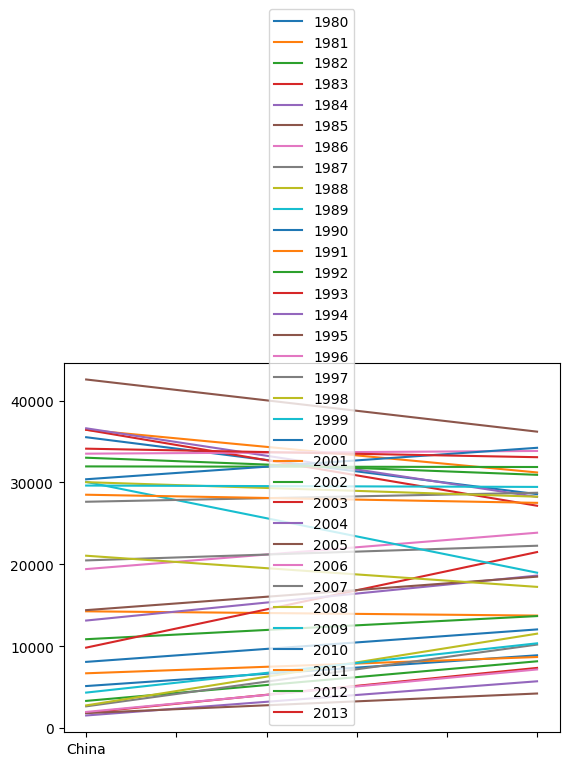

In [48]:
df_ci= df_can.loc[['China', 'India'], years]
df_ci.plot();

*pandas* plots the indices on the x-axis and the columns as individual lines on the y-axis. Since `df_CI` is a dataframe with the `country` as the index and `years` as the columns, I first transpose the dataframe using `transpose()` method to swap the row and columns.

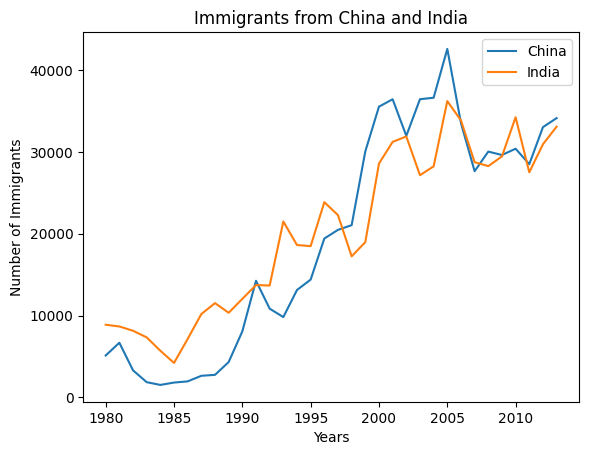

In [49]:
df_ci = df_ci.transpose()
df_ci.index = df_ci.index.map(int) # changing the index to integer

df_ci.plot()
plt.title('Immigrants from China and India')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')
plt.show();

I can observe that the China and India have very similar immigration trends through the years. 

`haiti` is a series as opposed to a dataframe, and has the years as its indices. That's why I need not to transpose Haiti's dataframe before plotting 

Comparing the trend of top 5 countries that contributed the most to immigration to Canada.

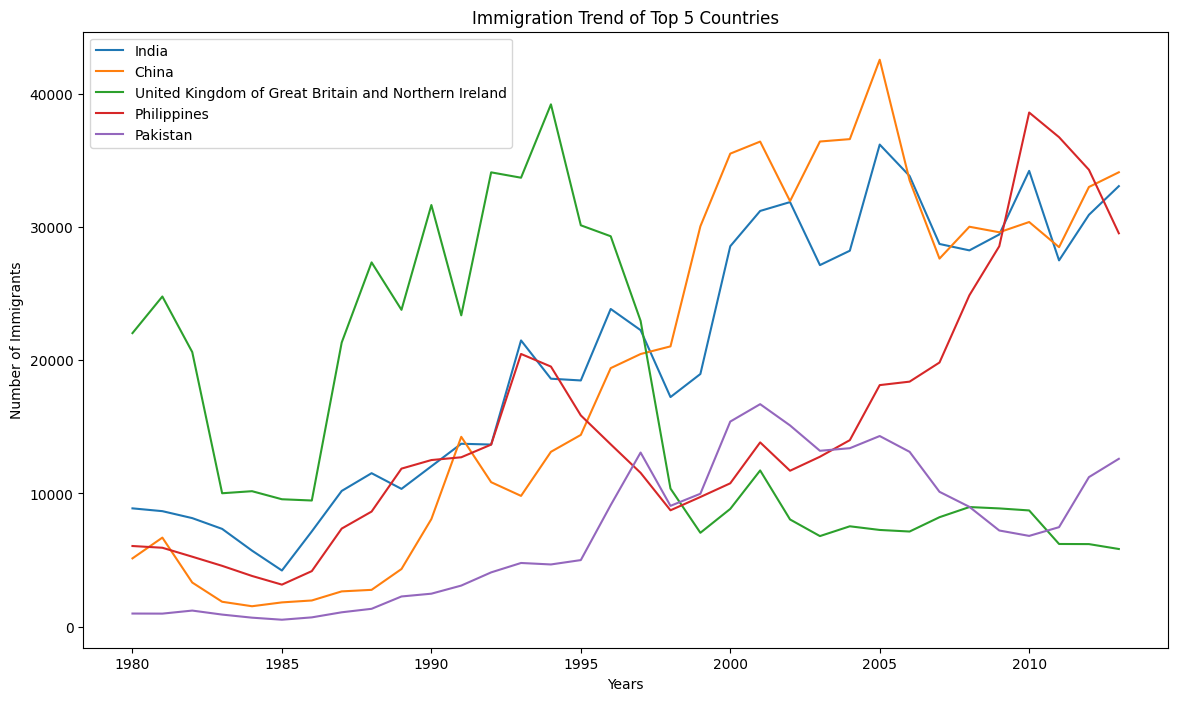

In [50]:
df_can.sort_values(by='Total', ascending=False, axis=0, inplace=True)
top_5 = df_can.head(5)
top_5 = top_5[years]
top_5 = top_5.transpose()
top_5.index = top_5.index.map(int)

top_5.plot(figsize=(14, 8))
plt.title('Immigration Trend of Top 5 Countries')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')
plt.show();

---

## Area Plots, Histograms, and Bar Charts

## Objectives

*   Create and customize 
    - Area plot
    - Histogram 
    - Bar charts on a dataset

## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">

1.  [Area Plots](#6) <br>
4.  [Histograms](#8) <br>
5.  [Bar Charts](#10) <br>

</div>

## Area Plots<a id="6"></a>



In [51]:
print('data dimensions:', df_can.shape)

data dimensions: (195, 38)


I created a line plot that visualized the top 5 countries that contribued the most immigrants to Canada from 1980 to 2013. With a little modification, I visualized the top 5 countries as a cumulative plot, also knows as a **Stacked Line Plot** or **Area plot**.

Area plots are stacked by default. And to produce a stacked area plot, each column must be either all positive or all negative values (any `NaN`, i.e. not a number, values will default to 0). To produce an unstacked plot, set parameter `stacked` to value `False`.

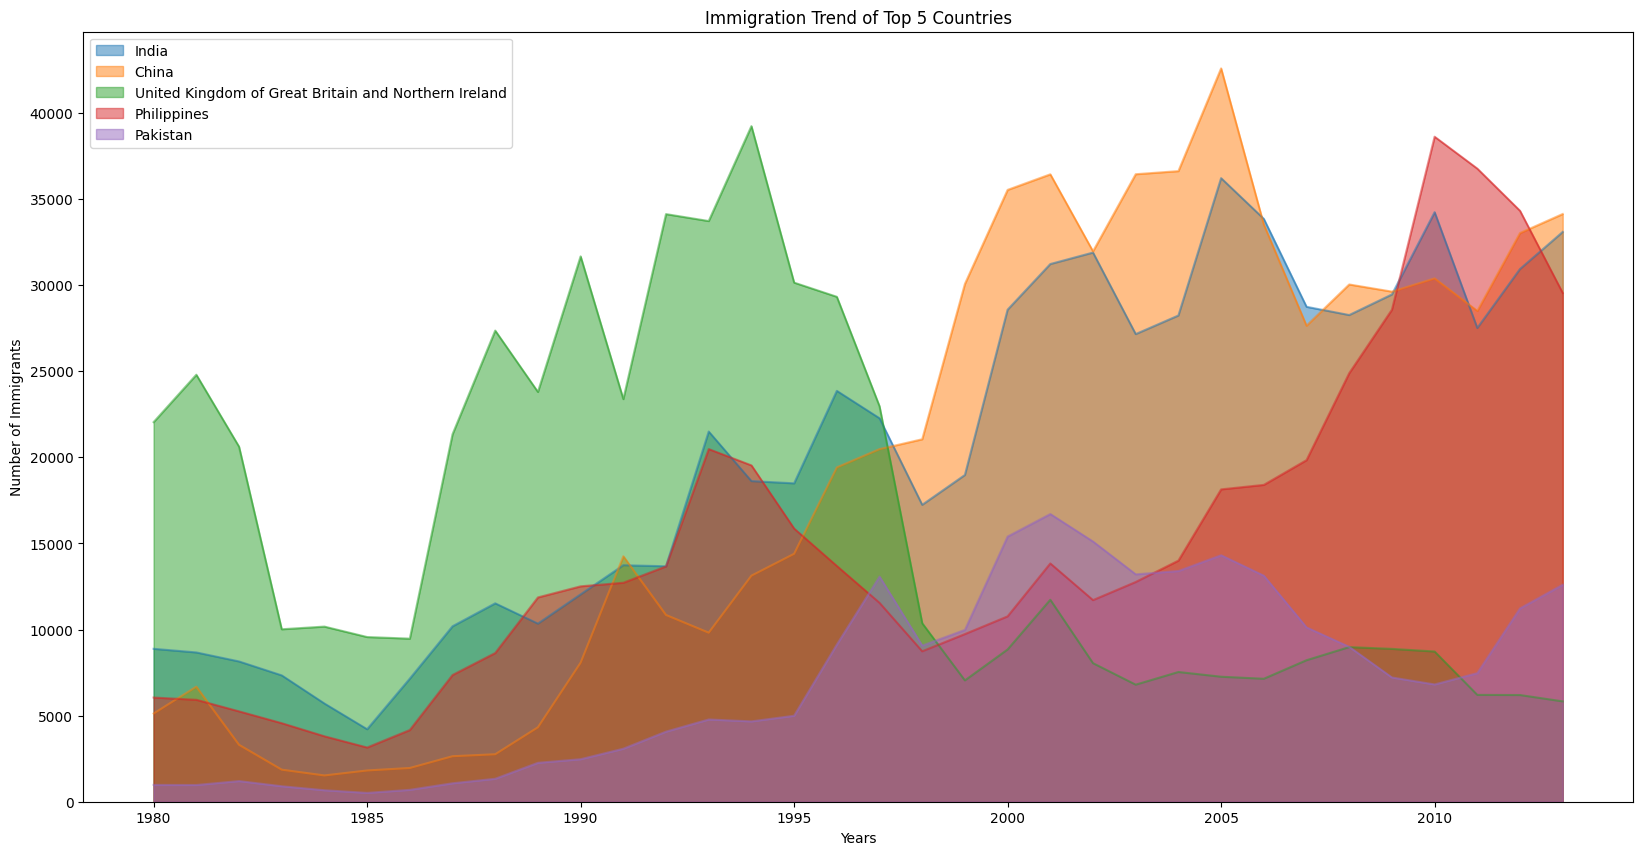

In [52]:
top_5.index = top_5.index.map(int)
top_5.plot(kind='area',
             stacked=False,
             figsize=(20, 10))  # pass a tuple (x, y) size

plt.title('Immigration Trend of Top 5 Countries')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')

plt.show()

The unstacked plot has a default transparency (alpha value) at 0.5. I modified this value by passing in the `alpha` parameter.

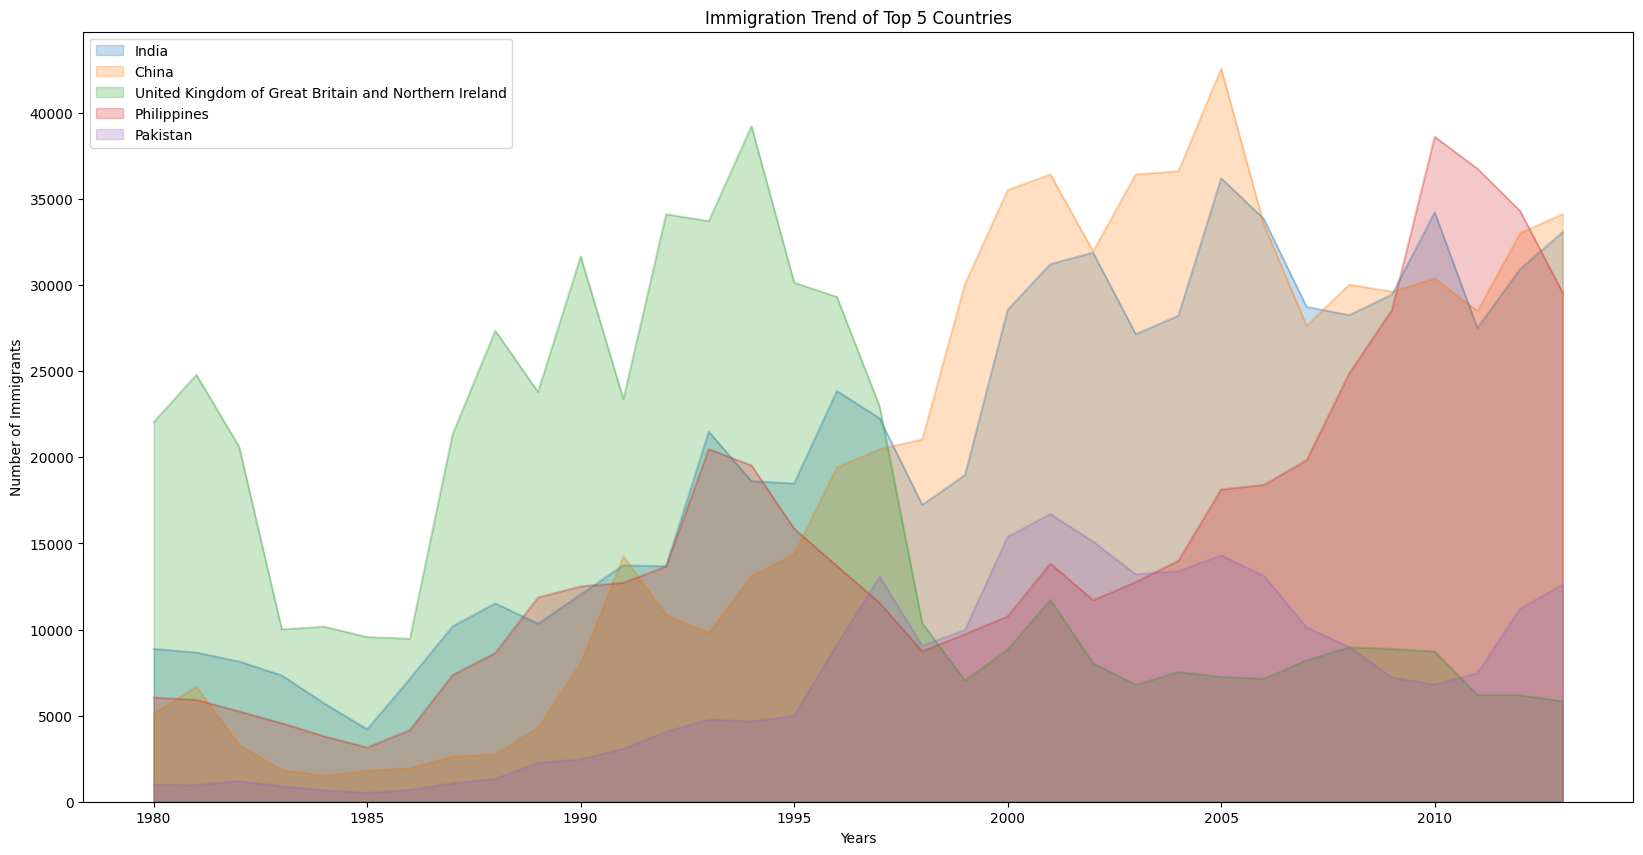

In [53]:
top_5.index = top_5.index.map(int)
top_5.plot(kind='area',
           alpha= 0.25,
           stacked=False,
           figsize=(20, 10))  

plt.title('Immigration Trend of Top 5 Countries')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')

plt.show();

There are two styles of plotting with `matplotlib`， plotting using the Artist layer and plotting using the scripting layer.

**Option 1: Scripting layer (procedural method) - using matplotlib.pyplot as 'plt'**

You can use `plt` i.e. `matplotlib.pyplot` and add more elements by calling different methods procedurally; for example, `plt.title(...)` to add title or `plt.xlabel(...)` to add label to the x-axis.

**Option 2: Artist layer (Object oriented method) - using an `Axes` instance from Matplotlib**

I can use an `Axes` instance of the current plot and store it in a variable (eg. `ax`). Then, I can add more elements by calling methods with a little change in syntax (by adding "`set_`" to the previous methods). For example, use `ax.set_title()` instead of `plt.title()` to add title,  or `ax.set_xlabel()` instead of `plt.xlabel()` to add label to the x-axis.

This option sometimes is more transparent and flexible to use for advanced plots (in particular when having multiple plots).

I sticked to the **scripting layer**, except for some advanced visualizations where I needed to use the **artist layer** to manipulate advanced aspects of the plots.

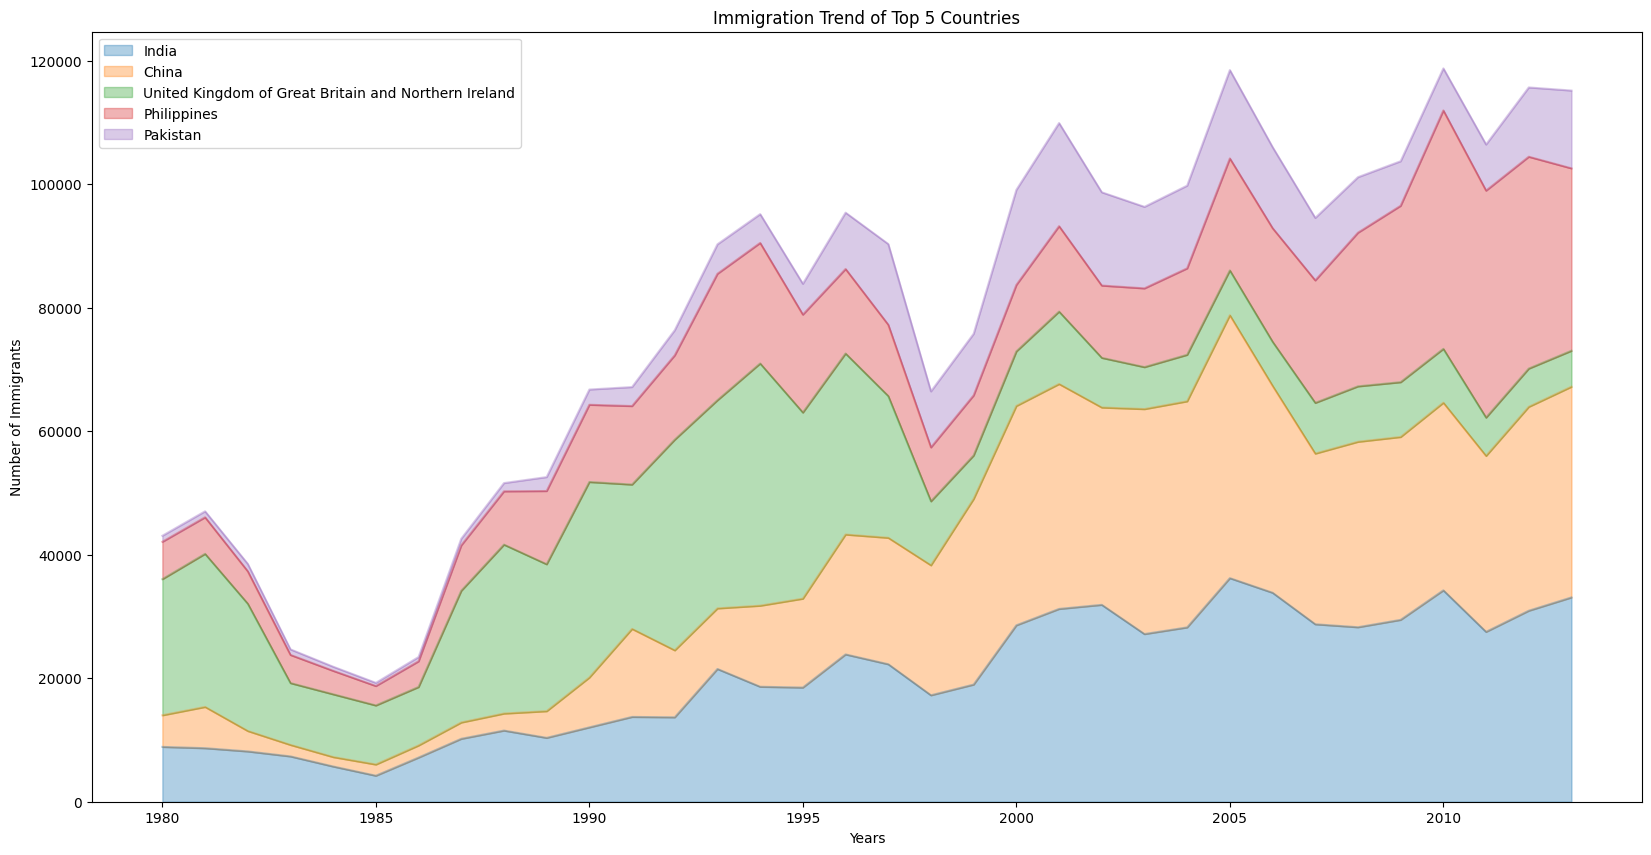

In [54]:
ax = top_5.plot(kind='area', alpha=0.35, figsize=(20, 10))

ax.set_title('Immigration Trend of Top 5 Countries')
ax.set_ylabel('Number of Immigrants')
ax.set_xlabel('Years');

Using the scripting layer to create a stacked area plot of the 5 countries that contributed the least to immigration to Canada **from** 1980 to 2013. Using a transparency value of 0.45.

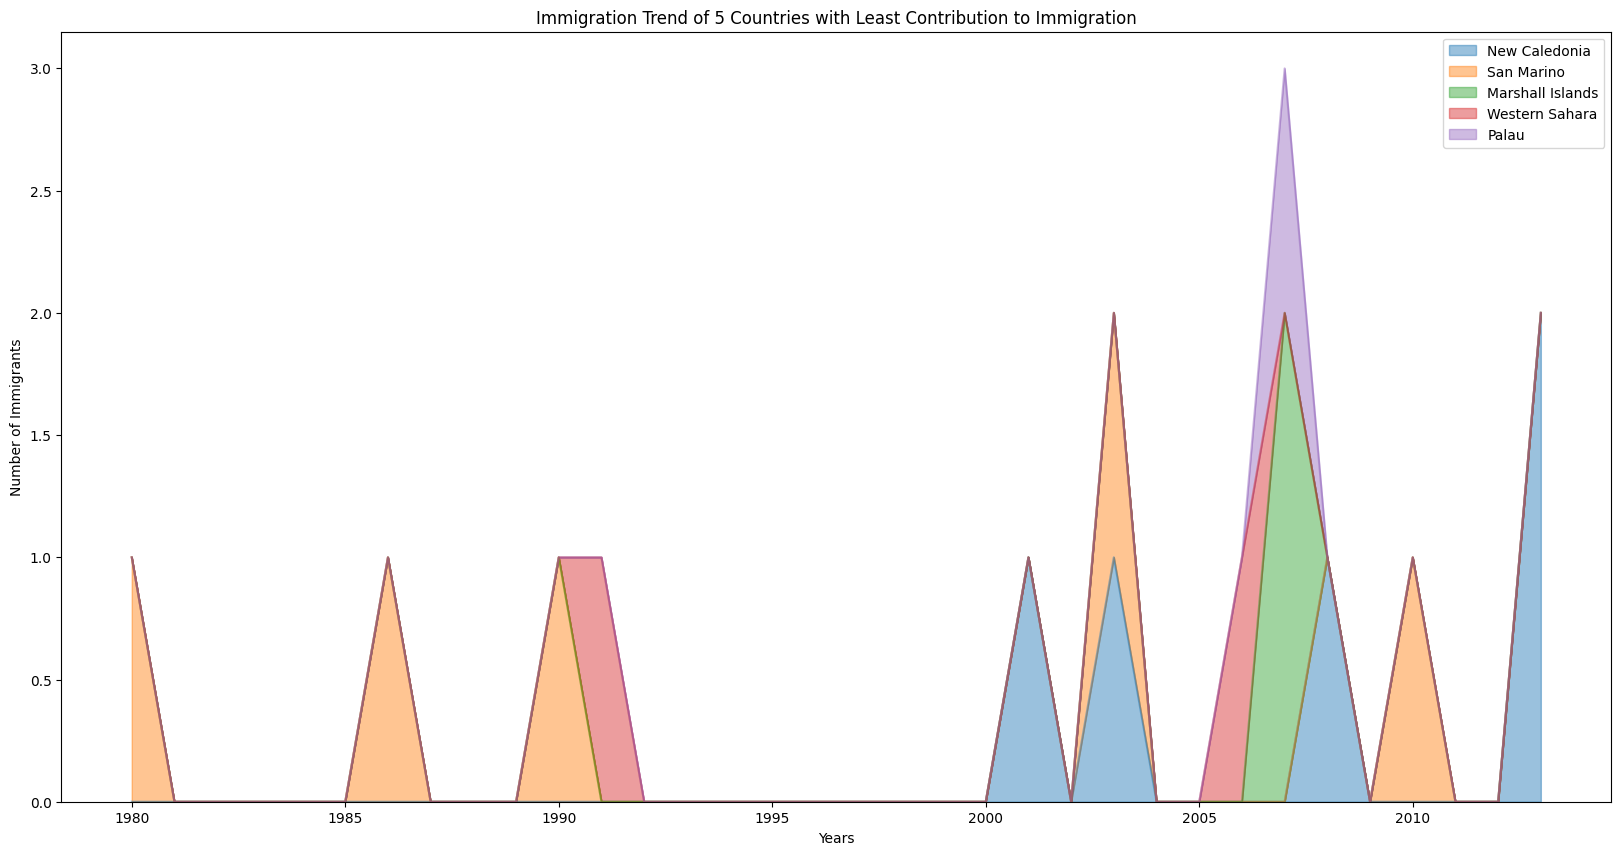

In [55]:
df_least5 = df_can.tail(5)
     
df_least5 = df_least5[years].transpose() 
df_least5.head()

df_least5.index = df_least5.index.map(int) 
df_least5.plot(kind='area', alpha=0.45, figsize=(20, 10)) 

plt.title('Immigration Trend of 5 Countries with Least Contribution to Immigration')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')

plt.show();

Using the artist layer to create an unstacked area plot of the 5 countries that contributed the least to immigration to Canada from 1980 to 2013. Using a transparency value of 0.55.

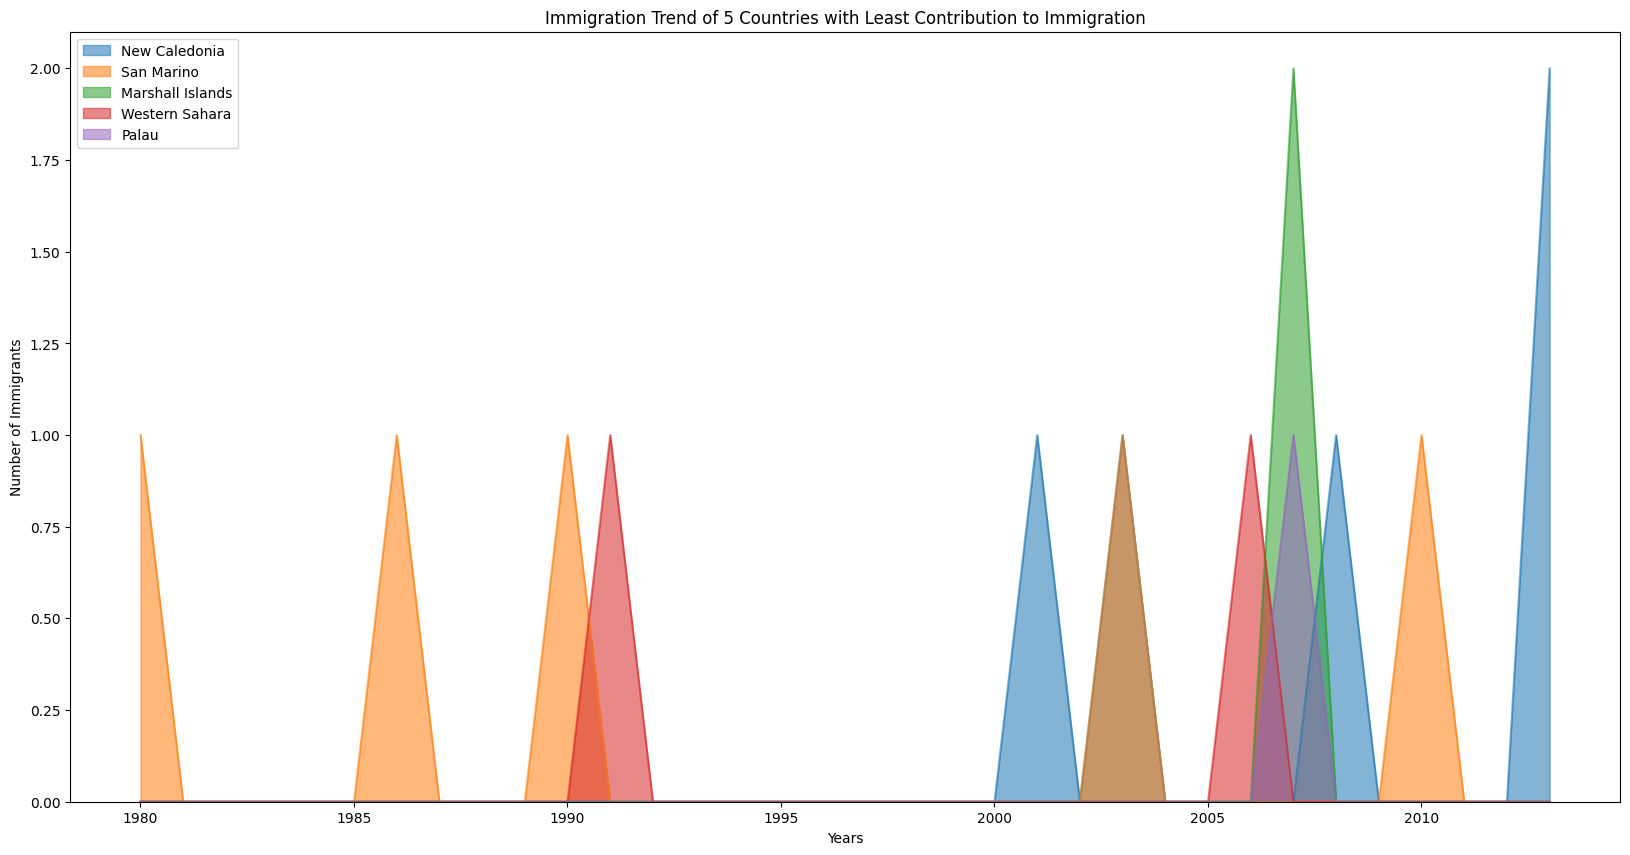

In [56]:
ax = df_least5.plot(kind='area', alpha=0.55, stacked=False, figsize=(20, 10))
    
ax.set_title('Immigration Trend of 5 Countries with Least Contribution to Immigration')
ax.set_ylabel('Number of Immigrants')
ax.set_xlabel('Years');

## Histograms<a id="8"></a>

A histogram is a way of representing the *frequency* distribution of numeric dataset. The way it works is it partitions the x-axis into *bins*, assigns each data point in the dataset to a bin, and then counts the number of data points that have been assigned to each bin. So the y-axis is the frequency or the number of data points in each bin.


Analzying frequency distribution of the number of new immigrants from the various countries to Canada in 2013

In [57]:
count, bin_edges = np.histogram(df_can['2013'])

print(count) # frequency count
print(bin_edges)

[178  11   1   2   0   0   0   0   1   2]
[    0.   3412.9  6825.8 10238.7 13651.6 17064.5 20477.4 23890.3 27303.2
 30716.1 34129. ]


By default, the `histrogram` method breaks up the dataset into 10 bins:

*   178 countries contributed between 0 to 3412.9 immigrants
*   11 countries contributed between 3412.9 to 6825.8 immigrants
*   1 country contributed between 6285.8 to 10238.7 immigrants

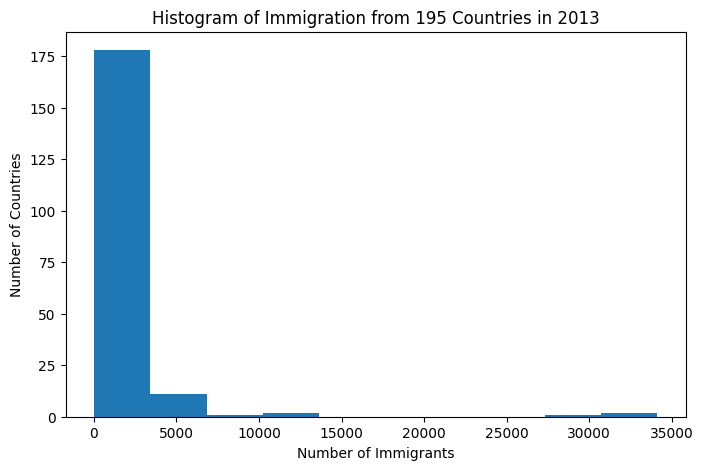

In [58]:
df_can['2013'].plot(kind='hist', figsize=(8, 5))

plt.title('Histogram of Immigration from 195 Countries in 2013')
plt.ylabel('Number of Countries')
plt.xlabel('Number of Immigrants')

plt.show()

Notice that the x-axis labels do not match with the bin size. This can be fixed by passing in a `xticks` keyword that contains the list of the bin sizes

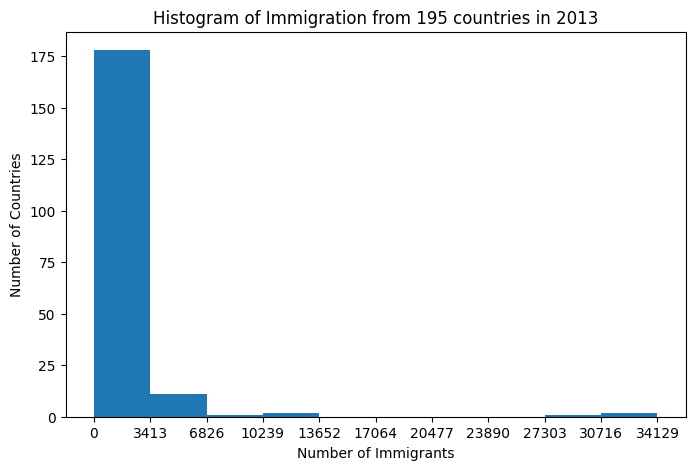

In [59]:
df_can['2013'].plot(kind='hist', figsize=(8, 5), xticks=bin_edges)

plt.title('Histogram of Immigration from 195 countries in 2013') 
plt.ylabel('Number of Countries') 
plt.xlabel('Number of Immigrants') 

plt.show()

In the above plot, the x-axis represents the population range of immigrants in intervals of 3412.9. The y-axis represents the number of countries that contributed to the before mentioned population.

Analzying immigration distribution for Denmark, Norway, and Sweden for years 1980 - 2013

In [60]:
df_dns= df_can.loc[['Denmark', 'Norway', 'Sweden'], years].transpose()
df_dns.index = df_dns.index.map(int)  # changing the index to integer

Adding a few modifications to improve the aesthetics of the plot:

*   increase the bin size to 15 by passing in `bins` parameter;
*   set transparency to 60% by passing in `alpha` parameter;
*   label the x-axis by passing in `x-label` parameter;
*   change the colors of the plots by passing in `color` parameter.

- I do not want the plots to overlap each other, so I stacked them using the `stacked` parameter. Adjusting the min and max x-axis labels to remove the extra gap on the edges of the plot. Passing a tuple (min,max) using the `xlim` paramater.


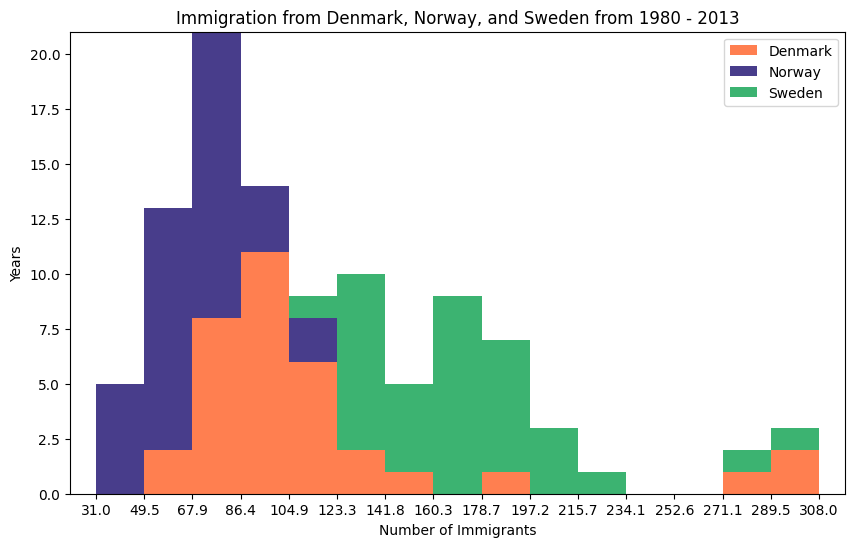

In [61]:
count, bin_edges = np.histogram(df_dns, 15)
xmin = bin_edges[0] - 10   
xmax = bin_edges[-1] + 10  

df_dns.plot(kind='hist',
          figsize=(10, 6), 
          bins=15,
          xticks=bin_edges,
          color=['coral', 'darkslateblue', 'mediumseagreen'],
          stacked=True,
          xlim=(xmin, xmax)
         )

plt.title('Immigration from Denmark, Norway, and Sweden from 1980 - 2013')
plt.ylabel('Years')
plt.xlabel('Number of Immigrants') 

plt.show();

Using the scripting layer to display the immigration distribution for Greece, Albania, and Bulgaria for years 1980 - 2013. Using an overlapping plot with 15 bins and a transparency value of 0.35.

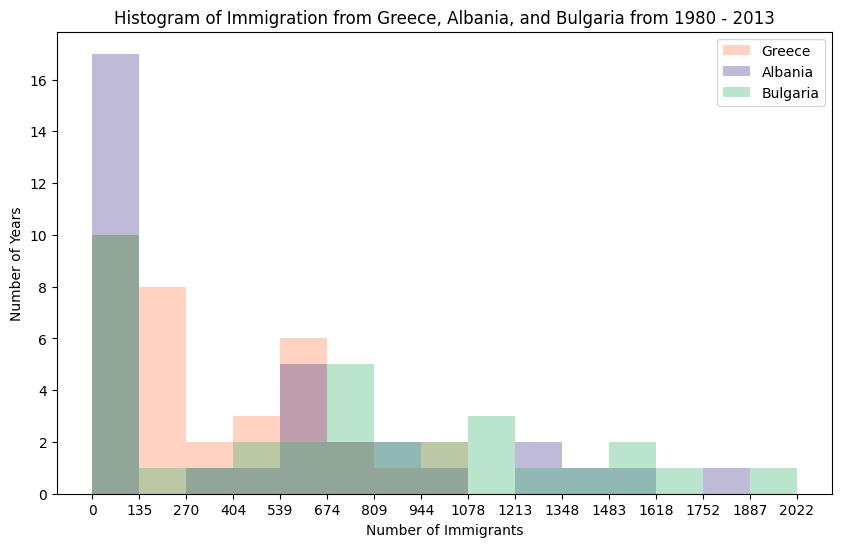

In [62]:
df_gab = df_can.loc[['Greece', 'Albania', 'Bulgaria'], years]
df_gab = df_gab.transpose() 
count, bin_edges = np.histogram(df_gab, 15)

df_gab.plot(kind ='hist',
            figsize=(10, 6),
            bins=15,
            alpha=0.35,
            xticks=bin_edges,
            color=['coral', 'darkslateblue', 'mediumseagreen']
            )

plt.title('Histogram of Immigration from Greece, Albania, and Bulgaria from 1980 - 2013')
plt.ylabel('Number of Years')
plt.xlabel('Number of Immigrants')

plt.show();

## Bar Charts <a id="10"></a>

A bar plot is a way of representing data where the *length* of the bars represents the magnitude/size of the feature/variable. Bar graphs usually represent numerical and categorical variables grouped in intervals.

To create a bar plot, pass one of two arguments via `kind` parameter in `plot()`:

*   `kind=bar` creates a *vertical* bar plot
*   `kind=barh` creates a *horizontal* bar plot


**Vertical bar plot**

In vertical bar graphs, the x-axis is used for labelling, and the length of bars on the y-axis corresponds to the magnitude of the variable being measured. Vertical bar graphs are particularly useful in analyzing time series data. One disadvantage is that they lack space for text labelling at the foot of each bar.

**Analyzing the effect of Iceland's Financial Crisis:**

The 2008 - 2011 Icelandic Financial Crisis was a major economic and political event in Iceland. Relative to the size of its economy, Iceland's systemic banking collapse was the largest experienced by any country in economic history. The crisis led to a severe economic depression in 2008 - 2011 and significant political unrest.

Comparing the number of Icelandic immigrants to Canada from year 1980 to 2013.

In [63]:
df_iceland = df_can.loc['Iceland', years]

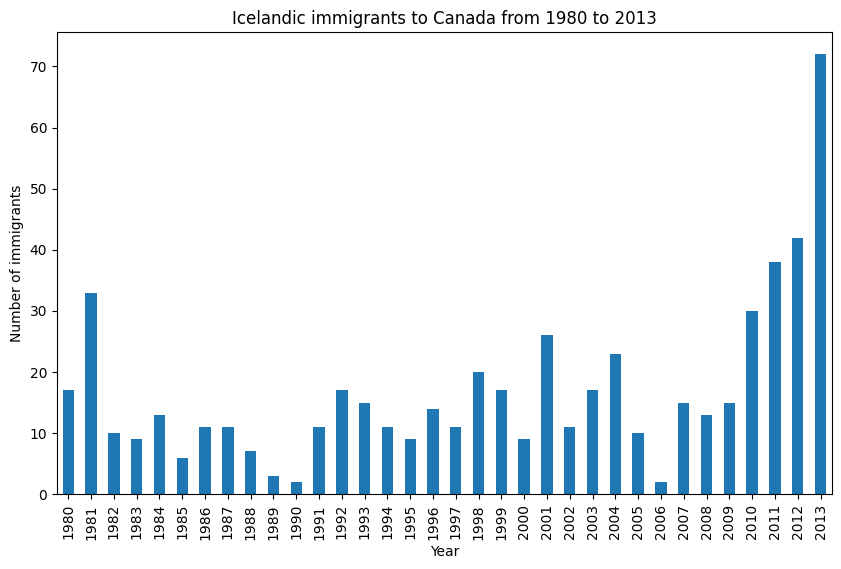

In [64]:
df_iceland.plot(kind='bar', figsize=(10, 6))

plt.xlabel('Year') # add to x-label to the plot
plt.ylabel('Number of immigrants') # add y-label to the plot
plt.title('Icelandic immigrants to Canada from 1980 to 2013') # add title to the plot

plt.show()

The bar plot above shows the total number of immigrants broken down by each year. I can clearly see the impact of the financial crisis; the number of immigrants to Canada started increasing rapidly after 2008.

Annotating this on the plot using the `annotate` method of the **scripting layer**.Passing in the following parameters:

*   `s`: str, the text of annotation.
*   `xy`: Tuple specifying the (x,y) point to annotate (in this case, end point of arrow).
*   `xytext`: Tuple specifying the (x,y) point to place the text (in this case, start point of arrow).
*   `xycoords`: The coordinate system that xy is given in - 'data' uses the coordinate system of the object being annotated (default).
*   `arrowprops`: Takes a dictionary of properties to draw the arrow:
    *   `arrowstyle`: Specifies the arrow style, `'->'` is standard arrow.
    *   `connectionstyle`: Specifies the connection type. `arc3` is a straight line.
    *   `color`: Specifies color of arrow.
    *   `lw`: Specifies the line width.

- For annotating a text to go over the arrow. Passing in the following additional parameters:

*   `rotation`: rotation angle of text in degrees (counter clockwise)
*   `va`: vertical alignment of text \[‘center’ | ‘top’ | ‘bottom’ | ‘baseline’]
*   `ha`: horizontal alignment of text \[‘center’ | ‘right’ | ‘left’]

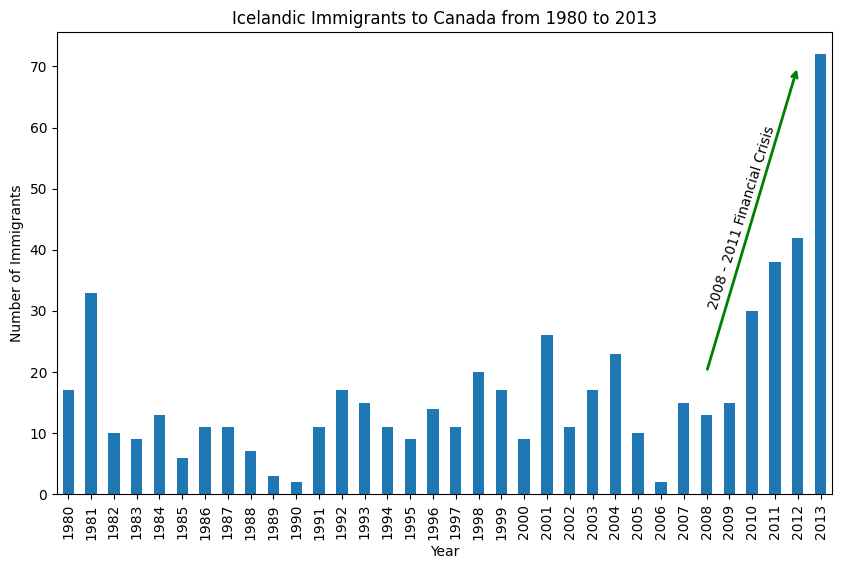

In [65]:

df_iceland.plot(kind='bar', figsize=(10, 6), rot=90)  # rotate the xticks by 90 degrees

plt.xlabel('Year')
plt.ylabel('Number of Immigrants')
plt.title('Icelandic Immigrants to Canada from 1980 to 2013')

# Annotating arrow
plt.annotate('',  # s: str. 
             xy=(32, 70),  # place head of the arrow at point (year 2012 , pop 70)
             xytext=(28, 20),  # place base of the arrow at point (year 2008 , pop 20)
             xycoords='data',  # will use the coordinate system of the object being annotated
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='green', lw=2)
             )

# Annotating Text
plt.annotate('2008 - 2011 Financial Crisis',  # text to display
             xy=(28, 30),  # start the text at at point (year 2008 , pop 30)
             rotation=72.5,  
             va='bottom',  # want the text to be vertically 'bottom' aligned
             ha='left',  # want the text to be horizontally 'left' algned.
             )

plt.show()

## **Horizontal Bar Plot**

Sometimes it is more practical to represent the data horizontally, especially if you need more room for labelling the bars. In horizontal bar graphs, the y-axis is used for labelling, and the length of bars on the x-axis corresponds to the magnitude of the variable being measured. 

Using the scripting later and the `df_can` dataset, I created a *horizontal* bar plot showing the *total* number of immigrants to Canada from the top 15 countries, for the period 1980 - 2013.

In [66]:
df_can.sort_values(by='Total', ascending=True, inplace=True)
df_top15 = df_can['Total'].tail(15)

Ploting the data:

1.  Using `kind='barh'` to generate a bar chart with horizontal bars.
3.  Looping through the countries and annotating the immigrant population using the anotate function of the scripting interface.


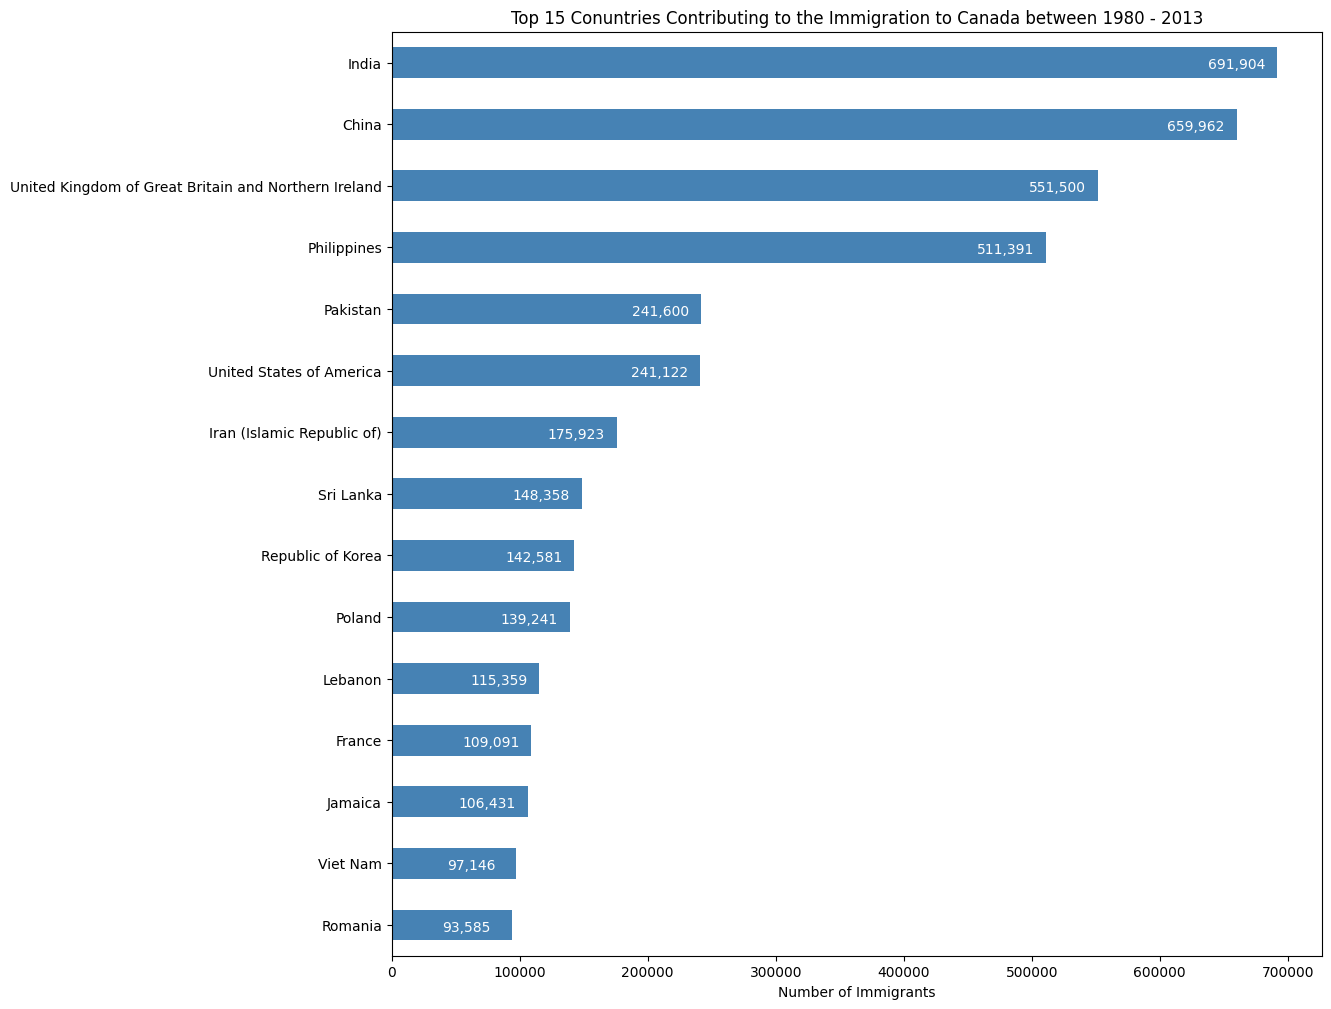

In [67]:
df_top15.plot(kind='barh', figsize=(12, 12), color='steelblue')
plt.xlabel('Number of Immigrants')
plt.title('Top 15 Conuntries Contributing to the Immigration to Canada between 1980 - 2013')

for index, value in enumerate(df_top15): 
    label = format(int(value), ',') # format int with commas
    
    # place text at the end of bar (subtracting 47000 from x, and 0.1 from y to make it fit within the bar)
    plt.annotate(label, xy=(value - 54000, index - 0.10), color='white')

plt.show()

---

## Pie Charts, Box Plots, Scatter Plots, and Bubble Plots


### Objectives

*   Create pie charts, box plots, scatter plots and bubble charts

### Pie Charts <a id="6"></a>

A `pie chart` is a circular graphic that displays numeric proportions by dividing a circle (or pie) into proportional slices. Pie charts as it is widely used in business and media. I created pie charts in Matplotlib by passing in the `kind=pie` keyword.

Using a pie chart to explore the proportion of new immigrants grouped by continents for the entire time period from 1980 to 2013.

In [68]:
df_continents = df_can.groupby('Continent', axis=0).sum()
df_continents.head()

,Region,DevName,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Continent,,,,,,,,,,,,,,,,,,,,,
Africa,Northern AfricaMiddle AfricaMiddle AfricaWeste...,Developing regionsDeveloping regionsDeveloping...,3951,4363,3819,2671,2639,2650,3782,7494,...,27523,29188,28284,29890,34534,40892,35441,38083,38543,618948
Asia,Southern AsiaWestern AsiaWestern AsiaEastern A...,Developing regionsDeveloping regionsDeveloping...,31025,34314,30214,24696,27274,23850,28739,43203,...,159253,149054,133459,139894,141434,163845,146894,152218,155075,3317794
Europe,Southern EuropeSouthern EuropeWestern EuropeWe...,Developed regionsDeveloped regionsDeveloped re...,39760,44802,42720,24638,22287,20844,24370,46698,...,35955,33053,33495,34692,35078,33425,26778,29177,28691,1410947
Latin America and the Caribbean,CaribbeanSouth AmericaCaribbeanCaribbeanCentra...,Developing regionsDeveloping regionsDeveloping...,13081,15215,16769,15427,13678,15171,21179,28471,...,24747,24676,26011,26547,26867,28818,27856,27173,24950,765148
Northern America,Northern AmericaNorthern America,Developed regionsDeveloped regions,9378,10030,9074,7100,6661,6543,7074,7705,...,8394,9613,9463,10190,8995,8142,7677,7892,8503,241142


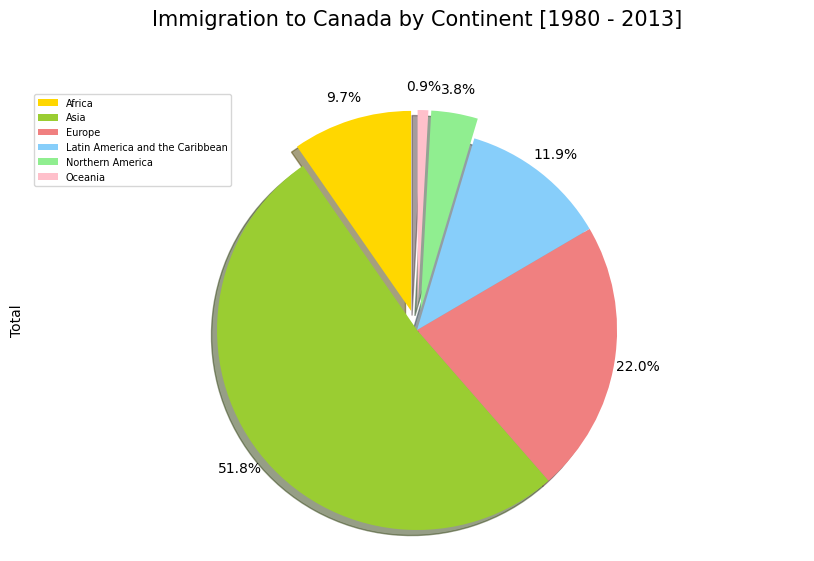

In [69]:
colors_list = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue', 'lightgreen', 'pink']
explode_list = [0.1, 0, 0, 0, 0.1, 0.1] # ratio for each continent with which to offset each wedge.

df_continents['Total'].plot(kind='pie',
                            figsize=(10, 6),
                            autopct='%1.1f%%', 
                            startangle=90,    
                            shadow=True,       
                            labels=None,         
                            pctdistance=1.12,    
                            colors=colors_list, 
                            explode=explode_list 
                            )

plt.title('Immigration to Canada by Continent [1980 - 2013]', y=1.12, fontsize = 15) 
plt.axis('equal') 
plt.legend(labels=df_continents.index, loc='upper left', fontsize=7) 

plt.show()

Using a pie chart, I explored the proportion of new immigrants grouped by continents in the year 2013.

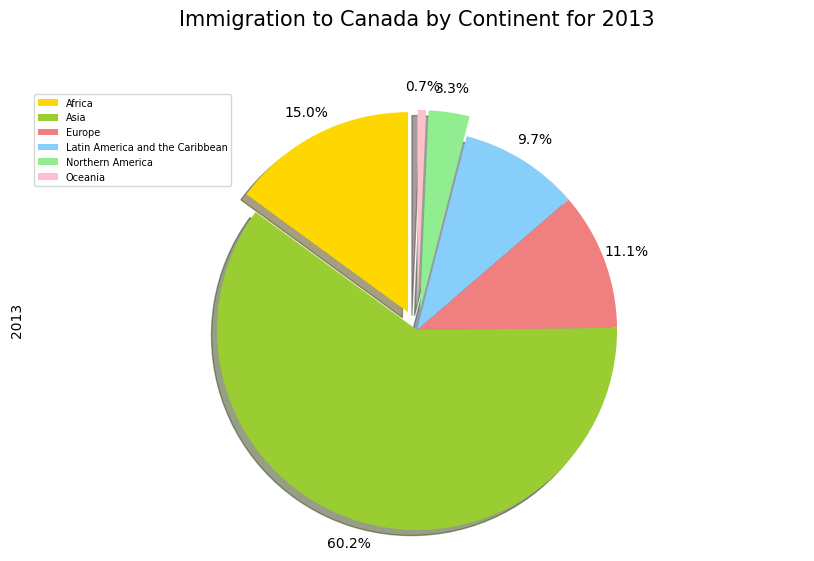

In [70]:
df_2013 = df_continents['2013']

colors_list = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue', 'lightgreen', 'pink']
explode_list = [0.1, 0, 0, 0, 0.1, 0.1] # ratio for each continent with which to offset each wedge.

df_2013.plot(kind='pie',
                            figsize=(10, 6),
                            autopct='%1.1f%%', 
                            startangle=90,    
                            shadow=True,       
                            labels=None,         
                            pctdistance=1.12,    
                            colors=colors_list, 
                            explode=explode_list 
                            )

plt.title('Immigration to Canada by Continent for 2013', y=1.12, fontsize = 15) 
plt.axis('equal') 
plt.legend(labels=df_2013.index, loc='upper left', fontsize=7) 

plt.show()

## Box Plots <a id="8"></a>

A `box plot` is a way of statistically representing the *distribution* of the data through five main dimensions:

*   **Minimum:** The smallest number in the dataset excluding the outliers.
*   **First quartile:** Middle number between the `minimum` and the `median`.
*   **Second quartile (Median):** Middle number of the (sorted) dataset.
*   **Third quartile:** Middle number between `median` and `maximum`.
*   **Maximum:** The largest number in the dataset excluding the outliers.

To make a `boxplot`, I used `kind=box` in `plot` method invoked on a *pandas* series or dataframe.

Ploting the box plot for the Japanese immigrants between 1980 - 2013.

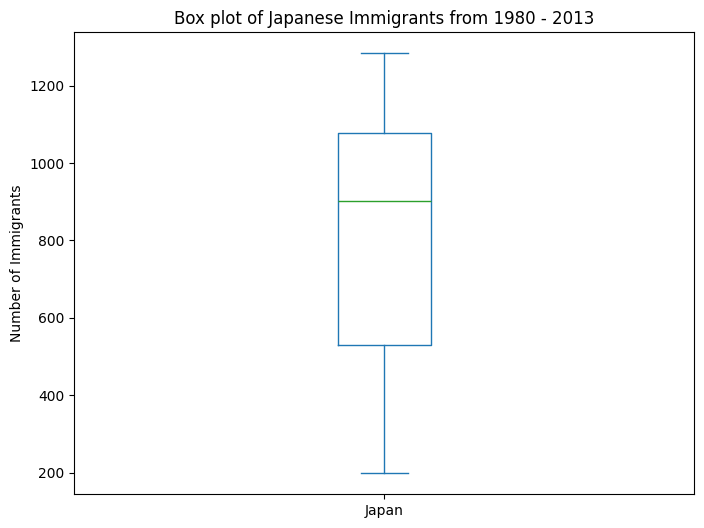

In [71]:
df_japan = df_can.loc[['Japan'], years].transpose()

df_japan.plot(kind='box', figsize=(8, 6))
plt.title('Box plot of Japanese Immigrants from 1980 - 2013')
plt.ylabel('Number of Immigrants')
plt.show();

#### Analysis:

1.  The minimum number of immigrants is around 200 (min), maximum number is around 1300 (max), and  median number of immigrants is around 900 (median).
2.  25% of the years for period 1980 - 2013 had an annual immigrant count of \~500 or fewer (First quartile).
3.  75% of the years for period 1980 - 2013 had an annual immigrant count of \~1100 or fewer (Third quartile).

Viewing the actual numbers by calling the `describe()` method on the dataframe.

In [72]:
df_japan.describe()

,Japan
count,34.000000
mean,814.911765
std,337.219771
min,198.000000
25%,529.000000
50%,902.000000
75%,1079.000000
max,1284.000000


One of the key benefits of box plots is comparing the distribution of multiple datasets. As observed that China and India had very similar immigration trends. 

Comparing the distribution of the number of new immigrants from India and China for the period 1980 - 2013.

In [73]:
df_ci.describe()

,China,India
count,34.000000,34.000000
mean,19410.647059,20350.117647
std,13568.230790,10007.342579
min,1527.000000,4211.000000
25%,5512.750000,10637.750000
50%,19945.000000,20235.000000
75%,31568.500000,28699.500000
max,42584.000000,36210.000000


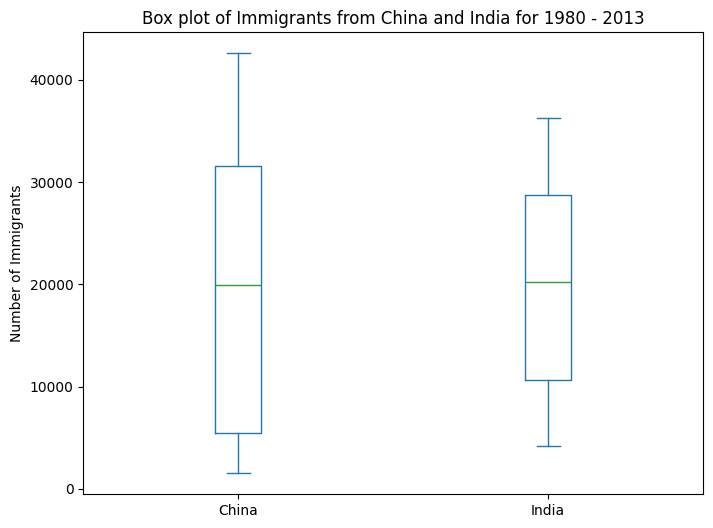

In [74]:
df_ci.plot(kind='box', figsize=(8, 6))
plt.title('Box plot of Immigrants from China and India for 1980 - 2013')
plt.ylabel('Number of Immigrants')
plt.show();

I can observe that, while both countries have around the same median immigrant population (\~20,000),  China's immigrant population range is more spread out than India's. The maximum population from India for any year (36,210) is around 15% lower than the maximum population from China (42,584).

#### **Subplots**

Ploting multiple plots within the same figure. For example, I performed a side by side comparison of the box plot with the line plot of China and India's immigration.

To visualize multiple plots together, I can create a **`figure`** and divide it into **`subplots`**, each containing a plot. 

Syntax is : <br>

```python
    fig = plt.figure() # create figure
    ax = fig.add_subplot(nrows, ncols, plot_number) # create subplots
```
Where

*   `nrows` and `ncols` are used to notionally split the figure into (`nrows` \* `ncols`) sub-axes,
*   `plot_number` is used to identify the particular subplot that this function is to create within the notional grid. `plot_number` starts at 1, increments across rows first and has a maximum of `nrows` \* `ncols` .


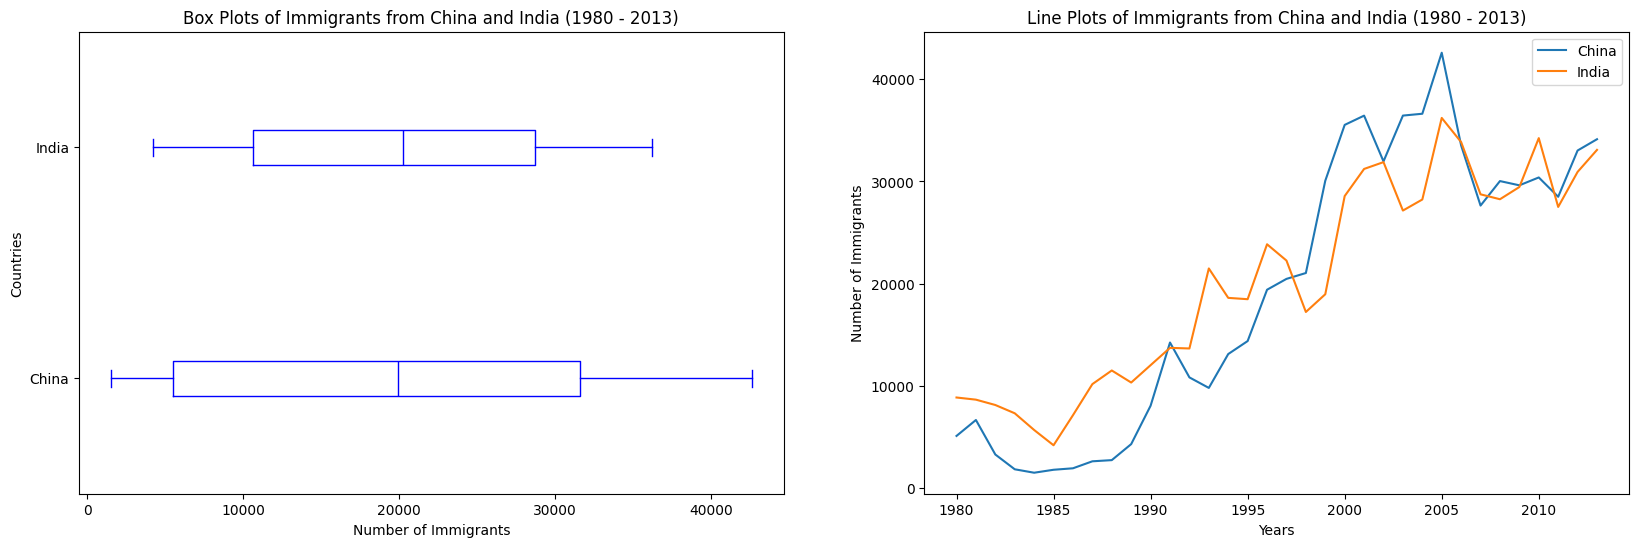

In [75]:
fig = plt.figure() # create figure

ax0 = fig.add_subplot(1, 2, 1) # add subplot 1 (1 row, 2 columns, first plot)
ax1 = fig.add_subplot(1, 2, 2) # add subplot 2 (1 row, 2 columns, second plot). See tip below**

# Subplot 1: Box plot
df_ci.plot(kind='box', color='blue', vert=False, figsize=(20, 6), ax=ax0) # add to subplot 1
ax0.set_title('Box Plots of Immigrants from China and India (1980 - 2013)')
ax0.set_xlabel('Number of Immigrants')
ax0.set_ylabel('Countries')

# Subplot 2: Line plot
df_ci.plot(kind='line', figsize=(20, 6), ax=ax1) # add to subplot 2
ax1.set_title ('Line Plots of Immigrants from China and India (1980 - 2013)')
ax1.set_ylabel('Number of Immigrants')
ax1.set_xlabel('Years')

plt.show()

In the case when `nrows`, `ncols`, and `plot_number` are all less than 10, a convenience exists such that a 3-digit number can be given instead, where the hundreds represent `nrows`, the tens represent `ncols` and the units represent `plot_number`. For instance,

```python
   subplot(211) == subplot(2, 1, 1) 
```

produces a subaxes in a figure which represents the top plot in a 2 rows by 1 column notional grid.

Previously, I identified the top 15 countries based on total immigration from 1980 - 2013.

Creating a box plot to visualize the distribution of the top 15 countries (based on total immigration) grouped by the *decades* `1980s`, `1990s`, and `2000s`.

In [76]:
years_80s = list(map(str, range(1980, 1990))) 
years_90s = list(map(str, range(1990, 2000))) 
years_00s = list(map(str, range(2000, 2010))) 

# slice the original dataframe df_can to create a series for each decade
df_80s = df_can.loc[df_top15.index, years_80s].sum(axis=1)
df_90s = df_can.loc[df_top15.index, years_90s].sum(axis=1)
df_00s = df_can.loc[df_top15.index, years_00s].sum(axis=1)

# merge the three series into a new data frame
new_df = pd.DataFrame({'1980s': df_80s, '1990s': df_90s, '2000s':df_00s}) 

# display dataframe
new_df.head()

,1980s,1990s,2000s
Romania,7613,33659,45515
Viet Nam,30638,37726,21274
Jamaica,34328,40329,22733
France,17137,30028,41297
Lebanon,24918,49245,30906


In [77]:
new_df.describe()

,1980s,1990s,2000s
count,15.000000,15.000000,15.000000
mean,44418.333333,85594.666667,97471.533333
std,44190.676455,68237.560246,100583.204205
min,7613.000000,30028.000000,13629.000000
25%,16698.000000,39259.000000,36101.500000
50%,30638.000000,56915.000000,65794.000000
75%,59183.000000,104451.500000,105505.500000
max,179171.000000,261966.000000,340385.000000


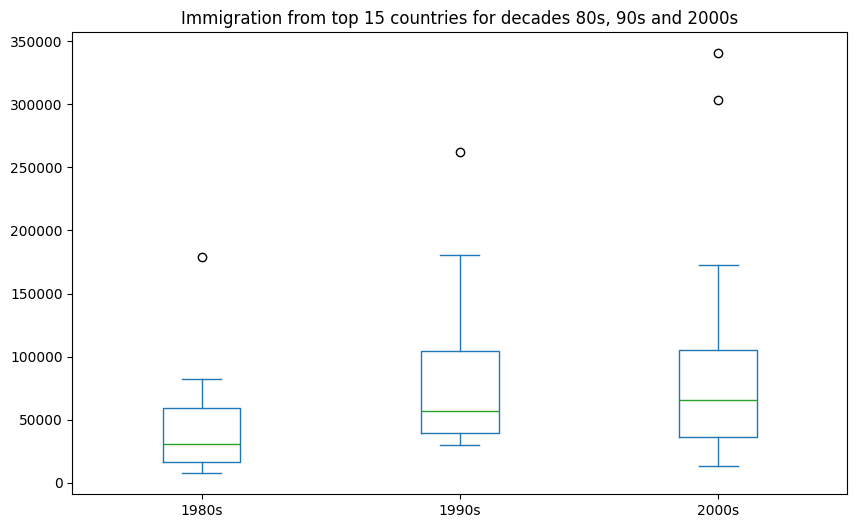

In [78]:
new_df.plot(kind='box', figsize=(10, 6))
plt.title('Immigration from top 15 countries for decades 80s, 90s and 2000s')
plt.show();

The box plot differs from the summary table created. The box plot scans the data and identifies the outliers. In order to be an outlier, the data value must be:<br>

*   larger than Q3 by at least 1.5 times the interquartile range (IQR), or,
*   smaller than Q1 by at least 1.5 times the IQR.

Let's look at decade 2000s as an example: <br>

*   Q1 (25%) = 36,101.5 <br>
*   Q3 (75%) = 105,505.5 <br>
*   IQR = Q3 - Q1 = 69,404 <br>

Using the definition of outlier, any value that is greater than Q3 by 1.5 times IQR will be flagged as outlier.

Outlier > 105,505.5 + (1.5 \* 69,404) <br>
Outlier > 209,611.5


In [79]:
new_df[new_df["2000s"] > 209611.5]

,1980s,1990s,2000s
China,32003,161528,340385
India,82154,180395,303591


China and India are both considered as outliers since their population for the decade exceeds 209,611.5.

## Scatter Plots <a id="10"></a>

A `scatter plot` (2D) is a useful method of comparing variables against each other. `Scatter` plots look similar to `line plots` in that they both map independent and dependent variables on a 2D graph. While the data points are connected together by a line in a line plot, they are not connected in a scatter plot. The data in a scatter plot is considered to express a trend. With further analysis using tools like regression, I mathematically calculated this relationship and use it to predict trends outside the dataset.


Using a `scatter plot`, visualizing the trend of total immigrantion to Canada (all countries combined) for the years 1980 - 2013.

In [80]:
df_tot = pd.DataFrame(df_can[years].sum(axis=0))
# changing the years to type int
df_tot.index = map(int, df_tot.index)

# reseting the index to put in back in as a column in the df_tot dataframe
df_tot.reset_index(inplace = True)
df_tot.columns = ['year', 'total']
df_tot.head()

,year,total
0,1980,99137
1,1981,110563
2,1982,104271
3,1983,75550
4,1984,73417


Ploting the data using a `scatter` plot set by passing in `kind='scatter'` as plot argument.

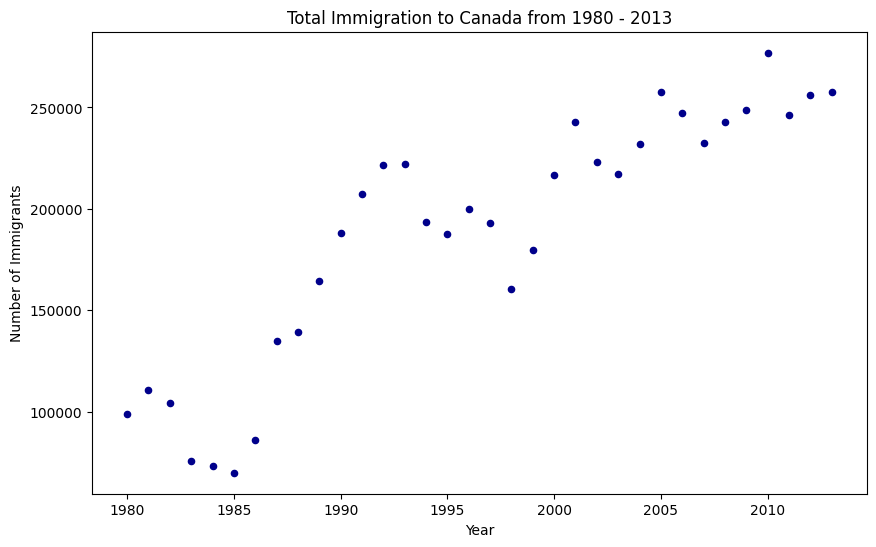

In [81]:
df_tot.plot(kind='scatter', x='year', y='total', figsize=(10, 6), color='darkblue')

plt.title('Total Immigration to Canada from 1980 - 2013')
plt.xlabel('Year')
plt.ylabel('Number of Immigrants')
plt.show();

The scatter plot does not connect the data  points together. I can clearly observe an upward trend in the data: as the years go by, the total number of immigrants increases. I mathematically analyzed this upward trend using a regression line (line of best fit).


Ploting a linear regression line, and use it to  predict the number of immigrants in 2015.

I used **Numpy**'s `polyfit()` method by passing in the following:

*   `x`: x-coordinates of the data.
*   `y`: y-coordinates of the data.
*   `deg`: Degree of fitting polynomial. 1 = linear, 2 = quadratic, and so on.

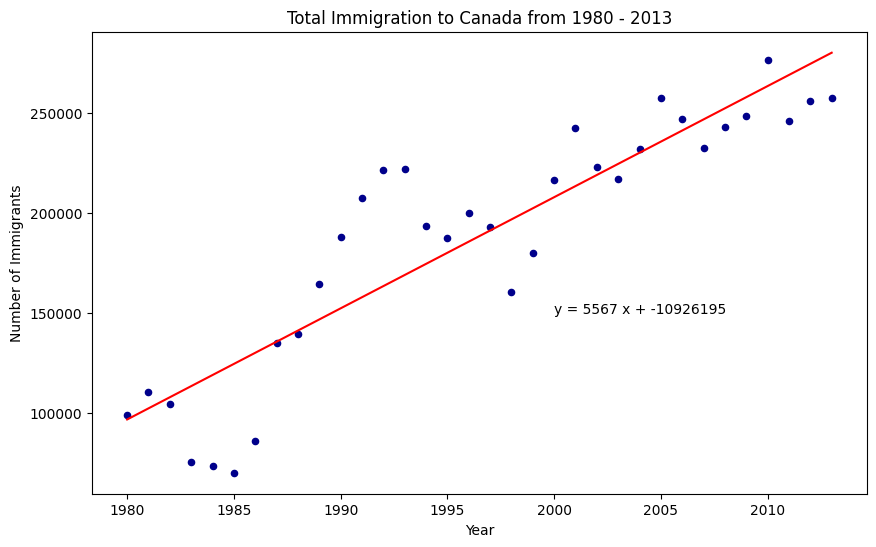

No. Immigrants = 5567 * Year + -10926195.


In [82]:
x = df_tot['year']     
y = df_tot['total']     
fit = np.polyfit(x, y, deg=1)

df_tot.plot(kind='scatter', x='year', y='total', figsize=(10, 6), color='darkblue')

plt.title('Total Immigration to Canada from 1980 - 2013')
plt.xlabel('Year')
plt.ylabel('Number of Immigrants')

# plot line of best fit
plt.plot(x, fit[0] * x + fit[1], color='red')
plt.annotate('y = {0:.0f} x + {1:.0f}'.format(fit[0], fit[1]), xy=(2000, 150000))
plt.show();

print(f'No. Immigrants = {fit[0]:.0f} * Year + {fit[1]:.0f}.')

Plotting the linear regression `y= a * x + b`, the output has 2 elements `[5567, -10926195]` with the the slope in position 0 and intercept in position 1.

Using the equation of line of best fit, I estimated the number of immigrants in 2015:

```python
No. Immigrants = 5567 * Year - 10926195
No. Immigrants = 5567 * 2015 - 10926195
No. Immigrants = 291,310
```

When compared to the actual from Citizenship and Immigration Canada's (CIC) [2016 Annual Report](http://www.cic.gc.ca/english/resources/publications/annual-report-2016/index.asp?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDV0101ENSkillsNetwork20297740-2021-01-01), I found that Canada accepted 271,845 immigrants in 2015. My estimated value of 291,310 is within 7% of the actual number, which is pretty good considering our original data came from United Nations (and might differ slightly from CIC data).

I also observed that immigration took a dip around 1993 - 1997. Further analysis into the topic revealed that in 1993 Canada introcuded Bill C-86 which introduced revisions to the refugee determination system, mostly restrictive. Further amendments to the Immigration Regulations cancelled the sponsorship required for "assisted relatives" and reduced the points awarded to them, making it more difficult for family members (other than nuclear family) to immigrate to Canada. These restrictive measures had a direct impact on the immigration numbers for the next several years.


Creating a scatter plot of the total immigration from Denmark, Norway, and Sweden to Canada from 1980 to 2013

In [83]:
df_total = pd.DataFrame(df_dns.sum(axis=1))
df_total.reset_index(inplace=True)
df_total.columns = ['year', 'total']

# change column year from string to int to create scatter plot
df_total['year'] = df_total['year'].astype(int)
df_total.head()

,year,total
0,1980,669
1,1981,678
2,1982,627
3,1983,333
4,1984,252


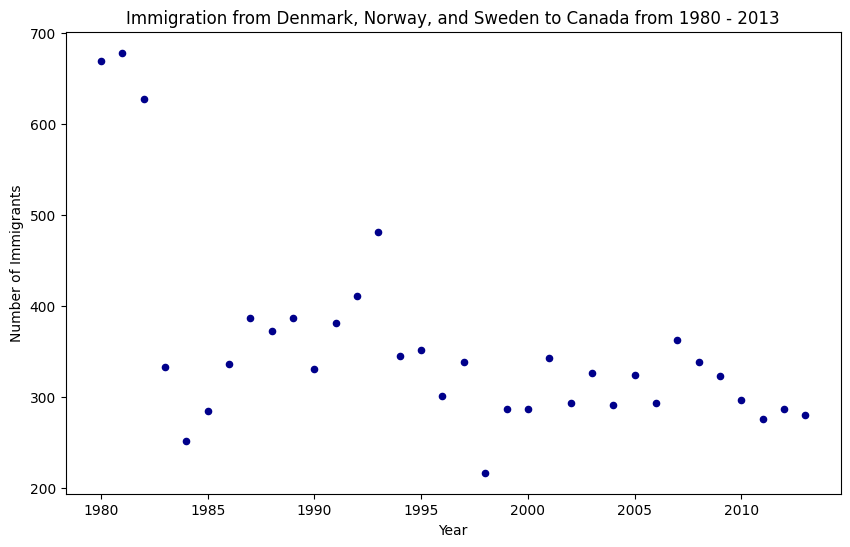

In [84]:
df_total.plot(kind='scatter', x='year', y='total', figsize=(10, 6), color='darkblue')

plt.title('Immigration from Denmark, Norway, and Sweden to Canada from 1980 - 2013')
plt.xlabel('Year')
plt.ylabel('Number of Immigrants')
plt.show();

## Bubble Plots <a id="12"></a>

A `bubble plot` is a variation of the `scatter plot` that displays three dimensions of data (x, y, z). The data points are replaced with bubbles, and the size of the bubble is determined by the third variable `z`, also known as the weight. In `maplotlib`, we can pass in an array or scalar to the parameter `s` to `plot()`, that contains the weight of each point.


**Analyzing the effect of Argentina's great depression**.

Argentina suffered a great depression from 1998 to 2002, which caused widespread unemployment, riots, the fall of the government, and a default on the country's foreign debt. In terms of income, over 50% of Argentines were poor, and seven out of ten Argentine children were poor at the depth of the crisis in 2002.

Analyzing the effect of this crisis, and comparing Argentina's immigration to that of it's neighbour Brazil. Using a `bubble plot` of immigration from Brazil and Argentina for the years 1980 - 2013. I set the weights for the bubble as the *normalized* value of the population for each year.

In [85]:
df_can_t = df_can[years].transpose()
df_can_t.index = map(int, df_can_t.index)
df_can_t.index.name = 'Year'
df_can_t.reset_index(inplace=True)
df_can_t.head()

,Year,Palau,Marshall Islands,Western Sahara,San Marino,New Caledonia,American Samoa,Tuvalu,Sao Tome and Principe,Vanuatu,...,Poland,Republic of Korea,Sri Lanka,Iran (Islamic Republic of),United States of America,Pakistan,Philippines,United Kingdom of Great Britain and Northern Ireland,China,India
0,1980,0,0,0,1,0,0,0,0,0,...,863,1011,185,1172,9378,978,6051,22045,5123,8880
1,1981,0,0,0,0,0,1,1,0,0,...,2930,1456,371,1429,10030,972,5921,24796,6682,8670
2,1982,0,0,0,0,0,0,0,0,0,...,5881,1572,290,1822,9074,1201,5249,20620,3308,8147
3,1983,0,0,0,0,0,0,0,0,0,...,4546,1081,197,1592,7100,900,4562,10015,1863,7338
4,1984,0,0,0,0,0,0,1,0,0,...,3588,847,1086,1977,6661,668,3801,10170,1527,5704


There are several methods of normalizations in statistics, each with its own use. I used [feature scaling](https://en.wikipedia.org/wiki/Feature_scaling?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDV0101ENSkillsNetwork20297740-2021-01-01) to bring all values into the range \[0, 1]. The general formula is:

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/Module%203/images/Mod3Fig3FeatureScaling.png" align="center">

where $X$ is the original value, $X'$ is the corresponding normalized value. The formula sets the max value in the dataset to 1, and sets the min value to 0. The rest of the data points are scaled to a value between 0-1 accordingly.


In [86]:
norm_brazil = (df_can_t['Brazil'] - df_can_t['Brazil'].min()) / (df_can_t['Brazil'].max() - df_can_t['Brazil'].min())
norm_argentina = (df_can_t['Argentina'] - df_can_t['Argentina'].min()) / (df_can_t['Argentina'].max() - df_can_t['Argentina'].min())

To plot two different scatter plots in one plot, I included the axes one plot into the other by passing it via the `ax` parameter.
*   I also passed in the weights using the `s` parameter. Given that the normalized weights are between 0-1, they won't be visible on the plot.
    *   multiply weights by 2000 to scale it up on the graph, and,
    *   add 10 to compensate for the min value (which has a 0 weight and therefore scale with $\times 2000$).


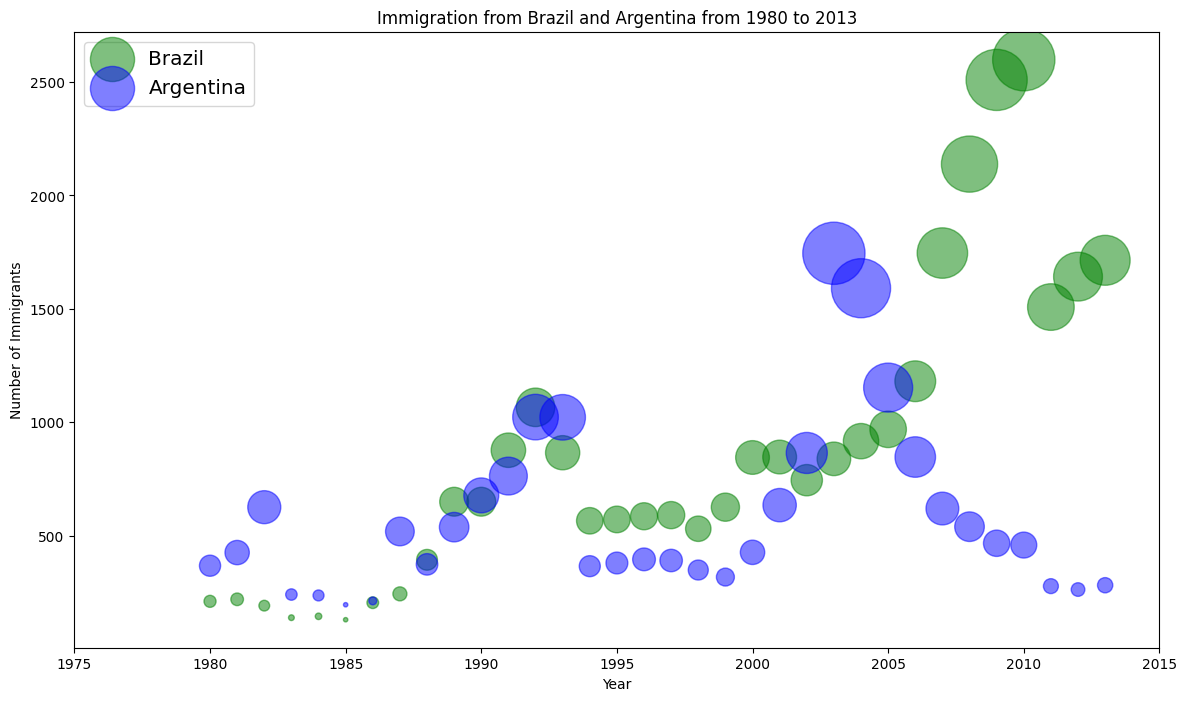

In [87]:
# Brazil
ax0 = df_can_t.plot(kind='scatter',
                    x='Year',
                    y='Brazil',
                    figsize=(14, 8),
                    alpha=0.5,  
                    color='green',
                    s=norm_brazil * 2000 + 10, 
                    xlim=(1975, 2015))

# Argentina
ax1 = df_can_t.plot(kind='scatter',
                    x='Year',
                    y='Argentina',
                    alpha=0.5,
                    color="blue",
                    s=norm_argentina * 2000 + 10,
                    ax=ax0)

ax0.set_ylabel('Number of Immigrants')
ax0.set_title('Immigration from Brazil and Argentina from 1980 to 2013')
ax0.legend(['Brazil', 'Argentina'], loc='upper left', fontsize='x-large');

The size of the bubble corresponds to the magnitude of immigrating population for that year, compared to the 1980 - 2013 data. The larger the bubble is, the more immigrants are in that year.

From the plot above, I noticed a corresponding increase in immigration from Argentina during the 1998 - 2002 great depression. I also observed a similar spike around 1985 to 1993. In fact, Argentina had suffered a great depression from 1974 to 1990, just before the onset of 1998 - 2002 great depression.

On a similar note, Brazil suffered the *Samba Effect* where the Brazilian real (currency) dropped nearly 35% in 1999. There was a fear of a South American financial crisis as many South American countries were heavily dependent on industrial exports from Brazil. The Brazilian government subsequently adopted an austerity program, and the economy slowly recovered over the years, culminating in a surge in 2010. The immigration data reflect these events.

Creating bubble plots of immigration from China and India to visualize any differences with time from 1980 to 2013. 

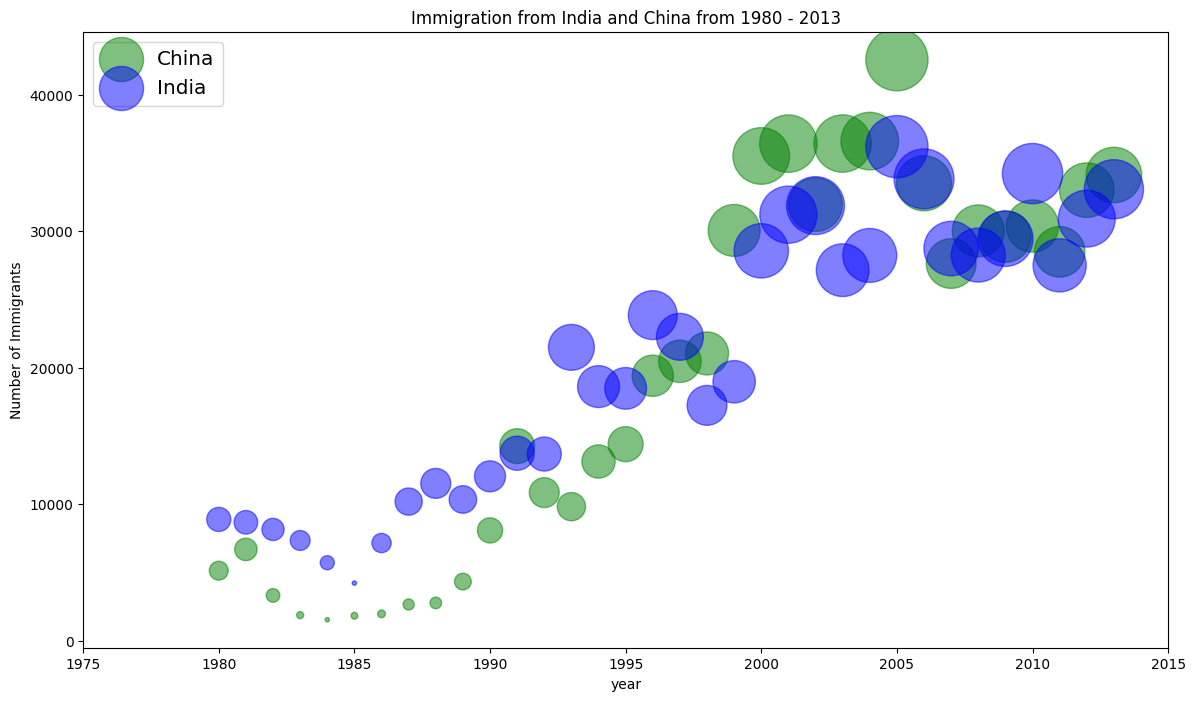

In [88]:
df_ci_plot = df_ci.copy()
df_ci_plot = df_ci_plot.reset_index().rename(columns={'index': 'year'})
df_ci_plot['year'] = df_ci_plot['year'].astype(int)

# Normalize for bubble size
norm_china = (df_ci_plot['China'] - df_ci_plot['China'].min()) / (df_ci_plot['China'].max() - df_ci_plot['China'].min())
norm_india = (df_ci_plot['India'] - df_ci_plot['India'].min()) / (df_ci_plot['India'].max() - df_ci_plot['India'].min())

# China
ax0 = df_ci_plot.plot(kind='scatter',
                      x='year',
                      y='China',
                      figsize=(14, 8),
                      alpha=0.5,
                      color='green',
                      s=norm_china * 2000 + 10,
                      xlim=(1975, 2015))

# India
ax1 = df_ci_plot.plot(kind='scatter',
                      x='year',
                      y='India',
                      alpha=0.5,
                      color="blue",
                      s=norm_india * 2000 + 10,
                      ax=ax0)

ax0.set_ylabel('Number of Immigrants')
ax0.set_title('Immigration from India and China from 1980 - 2013')
ax0.legend(['China', 'India'], loc='upper left', fontsize='x-large');

---

# Plotting directly with Matplotlib

### Objectives


*   Create and customize basic plots directly with Matplotlib on dataset

## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">

1.  [Import Libraries](#0)<br>
2.  [Fetching Data](#1) <br>
3.  [Line Plot](#6) <br>
4.  [Scatter Plot](#8) <br>
5.  [Bar Plot](#10) <br>
6.  [Histogram](#12) <br>
7.  [Pie](#14) <br>
8.  [Subplotting](#16) <br>
</div>

## Line Plot

A line plot displays the relationship between two continuous variables over a continuous interval, showing the trend or pattern of the data.<br><br>Let's created a line plot to visualize the immigrants (to Canada) trend during 1980 to 2013.<br>We need the Total of year-wise immigrants,<br><br>We will create a new dataframe for only columns containing the years<br> then, we will apply sum() on the dataframe<br><br>You can do create a line plot directly on **axes** by calling plot function **plot()**

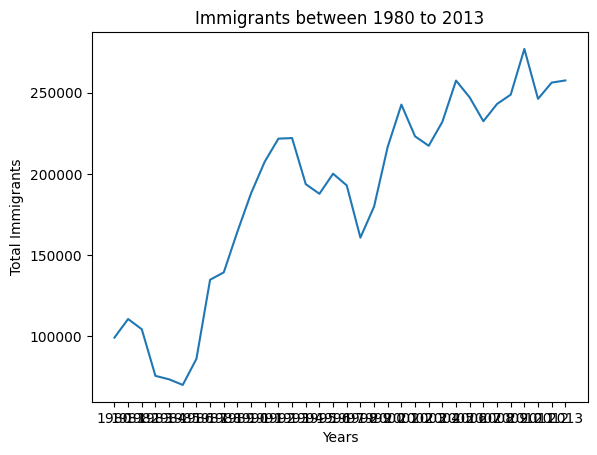

In [89]:
df_line=df_can[years]
total_immigrants=df_line.sum()
total_immigrants

fig, ax = plt.subplots()

# Plot the line
ax.plot(total_immigrants)

#Setting up the Title
ax.set_title('Immigrants between 1980 to 2013') 
#Setting up the Labels
ax.set_xlabel('Years')
ax.set_ylabel('Total Immigrants')

#Display the plot
plt.show()

The plot function populated the x-axis with the index values (years), and the y-axis with the column values (population). <br>However, the years were not displayed because they are of type string.<br> <br>Therefore, let's change the type of the index values to integer for plotting.

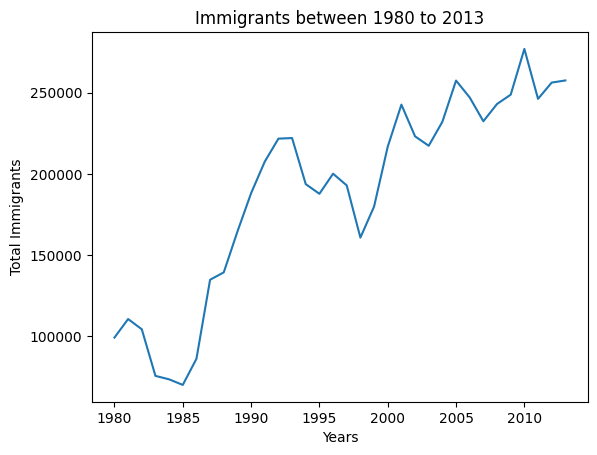

In [90]:
fig, ax = plt.subplots()

#Changing the index type to integer
total_immigrants.index = total_immigrants.index.map(int)

ax.plot(total_immigrants)
ax.set_title('Immigrants between 1980 to 2013') 
ax.set_xlabel('Years')
ax.set_ylabel('Total Immigrants')
plt.show()

Customizing above plot's appearance 

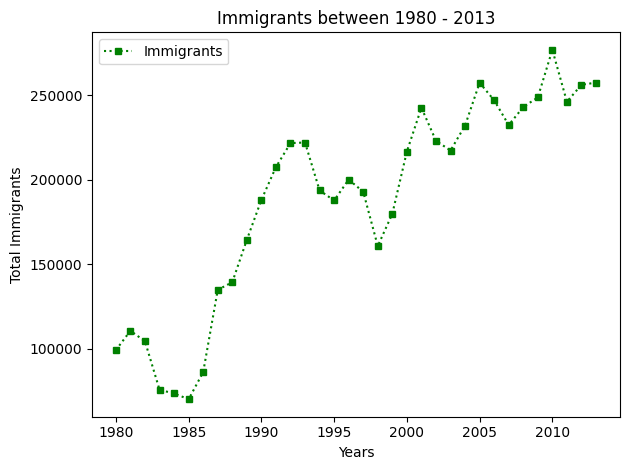

In [91]:
fig, ax = plt.subplots()
total_immigrants.index = total_immigrants.index.map(int)

# Customizing the appearance of Plot
ax.plot(total_immigrants, 
        marker='s', #Including markers in squares shapes
        markersize=5, #Setting the size of the marker
        color='green', #Changing the color of the line
        linestyle="dotted") #Changing the line style to a Dotted line
ax.set_title('Immigrants between 1980 - 2013') 
ax.set_xlabel('Years')
ax.set_ylabel('Total Immigrants')
ax.legend(['Immigrants'])
plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
plt.show()

---
# Scatter Plot<a id="8"></a>

A scatter plot visualizes the relationship between two continuous variables, displaying individual data points as dots on a two-dimensional plane, allowing for the examination of patterns, clusters, and correlations.

Creating a *Scatter plot* to visualize the immigrants (to Canada) trend during 1980 to 2013.


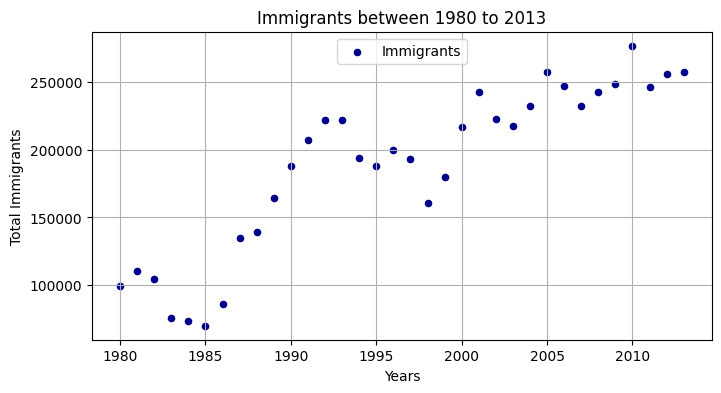

In [92]:
fig, ax = plt.subplots(figsize=(8, 4))

total_immigrants.index = total_immigrants.index.map(int)

# Customizing Scatter Plot 
ax.scatter(total_immigrants.index, total_immigrants, 
           marker='o', #setting up the markers
           s = 20, #setting up the size of the markers
           color='darkblue')#the color for the marker

plt.title('Immigrants between 1980 to 2013') 
plt.xlabel('Years')
plt.ylabel('Total Immigrants') 
plt.grid(True)
ax.legend(["Immigrants"], loc='upper center')
plt.show()

---
## Bar Plot

A bar plot represents categorical data with rectangular bars, where the height of each bar corresponds to the value of a specific category, making it suitable for comparing values across different categories.

Creating a bar plot to visualize the top 5 countries that contribued the most immigrants to Canada from 1980 to 2013. 

In [93]:
top_5 = df_can.sort_values(by='Total', ascending=False, axis=0).head(5)
top_5.index

Index(['India', 'China',
       'United Kingdom of Great Britain and Northern Ireland', 'Philippines',
       'Pakistan'],
      dtype='object')

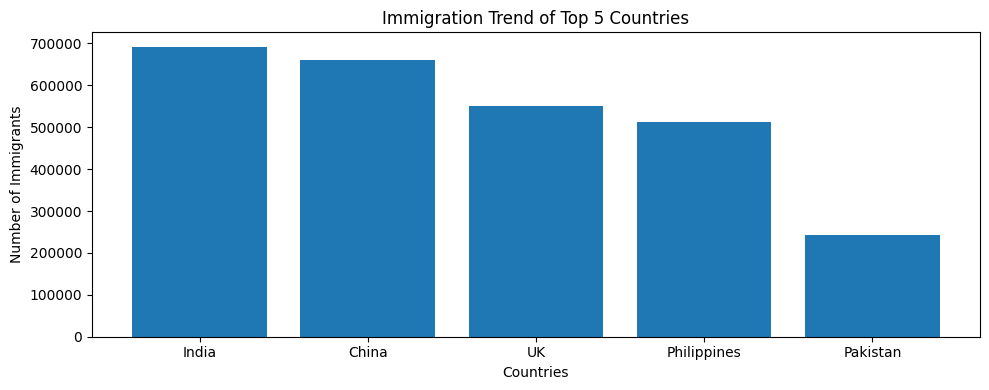

In [94]:

label = top_5.index.tolist()  # get the index of top 5 countries
label[2]= "UK" 
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(label,top_5['Total'], label= label)
ax.set_title('Immigration Trend of Top 5 Countries')
ax.set_ylabel('Number of Immigrants')
ax.set_xlabel('Countries')
plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
plt.show();

Creating a bar plot of the 5 countries that contributed the **least** to immigration to Canada **from** 1980 to 2013. 

In [95]:
least_5 = df_can.sort_values(by='Total', ascending=True, axis=0).head(5)
least_5.index

Index(['Palau', 'Marshall Islands', 'Western Sahara', 'San Marino',
       'New Caledonia'],
      dtype='object')

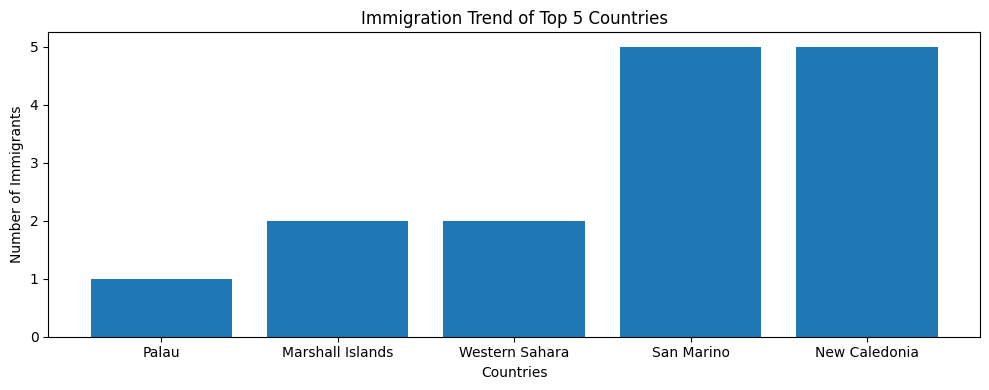

In [96]:
label = least_5.index.tolist()  # get the index of top 5 countries
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(label, least_5['Total'], label= label)
ax.set_title('Immigration Trend of Top 5 Countries')
ax.set_ylabel('Number of Immigrants')
ax.set_xlabel('Countries')
plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
plt.show();

## Histogram <a id="12"></a>

A histogram is a way of representing the *frequency* distribution of numeric dataset. The way it works is it partitions the x-axis into *bins*, assigns each data point in our dataset to a bin, and then counts the number of data points that have been assigned to each bin. So the y-axis is the frequency or the number of data points in each bin. Note that we can change the bin size and usually one needs to tweak it so that the distribution is displayed nicely.

Visualizing the immigration distribution for Denmark, Norway, and Sweden for years 1980 - 2013

In [97]:
df_dns=df_can.loc[['Denmark', 'Norway', 'Sweden'], years]
df_dns=df_dns.T
df_dns

,Denmark,Norway,Sweden
1980,272,116,281
1981,293,77,308
1982,299,106,222
1983,106,51,176
1984,93,31,128
1985,73,54,158
1986,93,56,187
1987,109,80,198
1988,129,73,171
1989,129,76,182


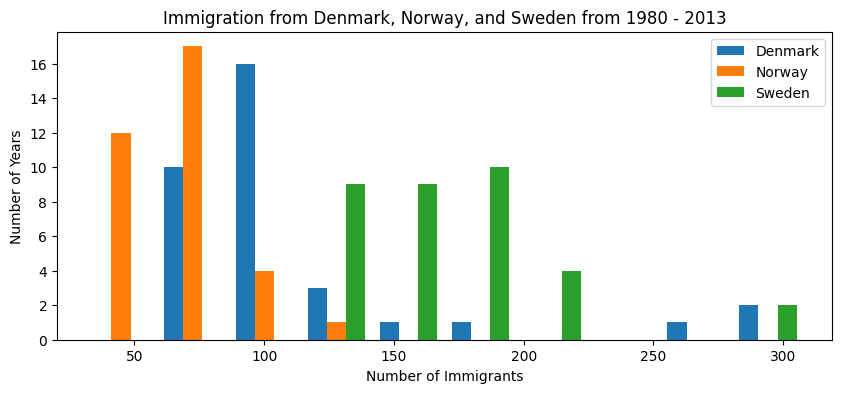

In [98]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_dns)
ax.set_title('Immigration from Denmark, Norway, and Sweden from 1980 - 2013') 
ax.set_xlabel('Number of Immigrants')
ax.set_ylabel('Number of Years')
ax.legend(['Denmark', 'Norway', 'Sweden'])
plt.show()

Visualizing the immigration distribution for China and India for years 2000 to 2013

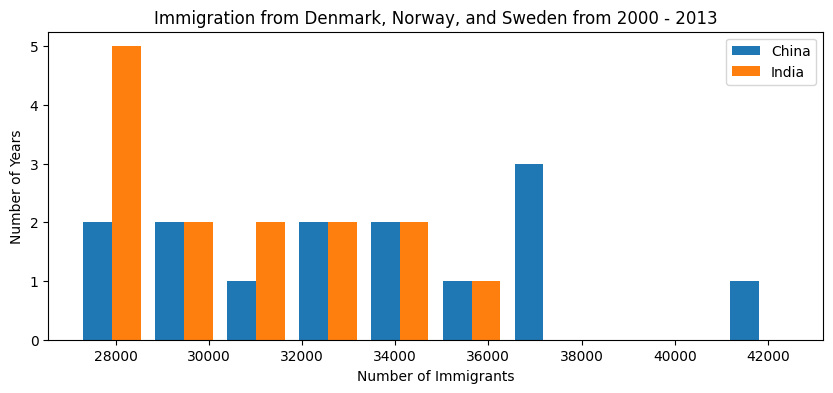

In [99]:
y=list(map(str,range(2000, 2014)))
df_ci=df_can.loc[['China', 'India'], y]
df_ci=df_ci.T
    
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_ci)
ax.set_title('Immigration from Denmark, Norway, and Sweden from 2000 - 2013') 
ax.set_xlabel('Number of Immigrants')
ax.set_ylabel('Number of Years')
ax.legend(['China', 'India'])
    
plt.show()

---
# Pie Chart<a id="14"></a>

A pie chart represents the proportion or percentage distribution of different categories in a dataset using sectors of a circular pie.

Creating a pie chart representing the 'Total Immigrants' for the year 1980 to 1985

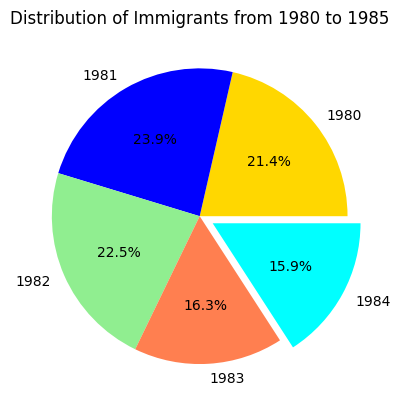

In [100]:
fig,ax=plt.subplots()

ax.pie(total_immigrants[0:5], labels=years[0:5], 
       colors = ['gold','blue','lightgreen','coral','cyan'],
       autopct='%1.1f%%',explode = [0,0,0,0,0.1]) #using explode to highlight the lowest 

ax.set_aspect('equal')

plt.title('Distribution of Immigrants from 1980 to 1985')
plt.show()

Creating a pie chart representing the total immigrants proportion for each continent

First, I grouped the data over continents like I previously did and get the sum on total.

In [101]:
df_con=df_can.groupby('Continent')['Total'].sum().reset_index()
df_con

,Continent,Total
0,Africa,618948
1,Asia,3317794
2,Europe,1410947
3,Latin America and the Caribbean,765148
4,Northern America,241142
5,Oceania,55174


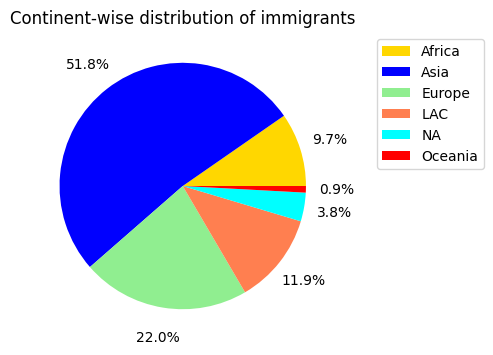

In [102]:
label=list(df_con.Continent)
label[3] = 'LAC'
label[4] = 'NA'
fig,ax=plt.subplots(figsize=(10, 4))

ax.pie(df_con['Total'], colors = ['gold','blue','lightgreen','coral','cyan','red'],
           autopct='%1.1f%%', pctdistance=1.25)

ax.set_aspect('equal')  # Ensure pie is drawn as a circle
plt.title('Continent-wise distribution of immigrants')
ax.legend(label,bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

----
# Sub-plotting<a id="18"></a>

Displaing more than one plot on the same figure and specifing the number of rows and columns to be created to the subplots function.  

Creating a line and scatter plot in one row 

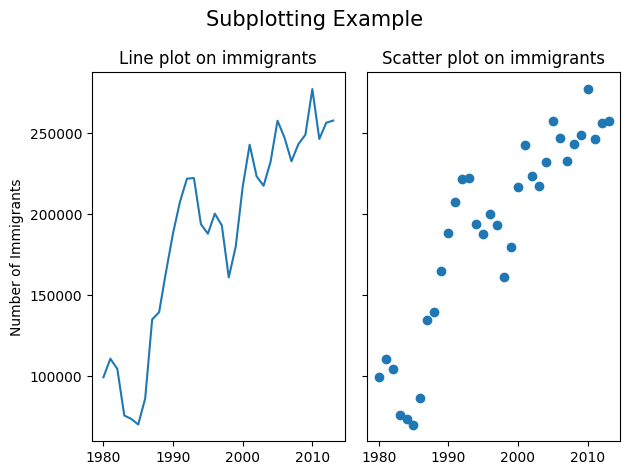

In [103]:
fig, axs = plt.subplots(1, 2, sharey=True)

#Plotting in first axes - the left one
axs[0].plot(total_immigrants)
axs[0].set_title("Line plot on immigrants")

#Plotting in second axes - the right one
axs[1].scatter(total_immigrants.index, total_immigrants)
axs[1].set_title("Scatter plot on immigrants")
axs[0].set_ylabel("Number of Immigrants")
            
#Adding a Title for the Overall Figure
fig.suptitle('Subplotting Example', fontsize=15)
fig.tight_layout()
plt.show()

Implement the subplotting with **add_subplot()**:

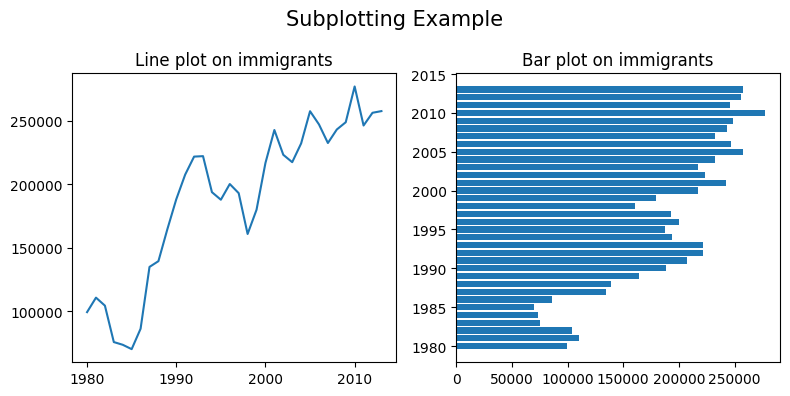

In [104]:
fig = plt.figure(figsize=(8,4))

# Add the first subplot (top-left)
axs1 = fig.add_subplot(1, 2, 1)
#Plotting in first axes - the left one
axs1.plot(total_immigrants)
axs1.set_title("Line plot on immigrants")

# Add the second subplot (top-right)
axs2 = fig.add_subplot(1, 2, 2)
#Plotting in second axes - the right one
axs2.barh(total_immigrants.index, total_immigrants) 
axs2.set_title("Bar plot on immigrants")
            
#Adding a Title for the Overall Figure
fig.suptitle('Subplotting Example', fontsize=15)

fig.tight_layout()
plt.show()

Subplotting and displaying previously created plots in a 2x2 display

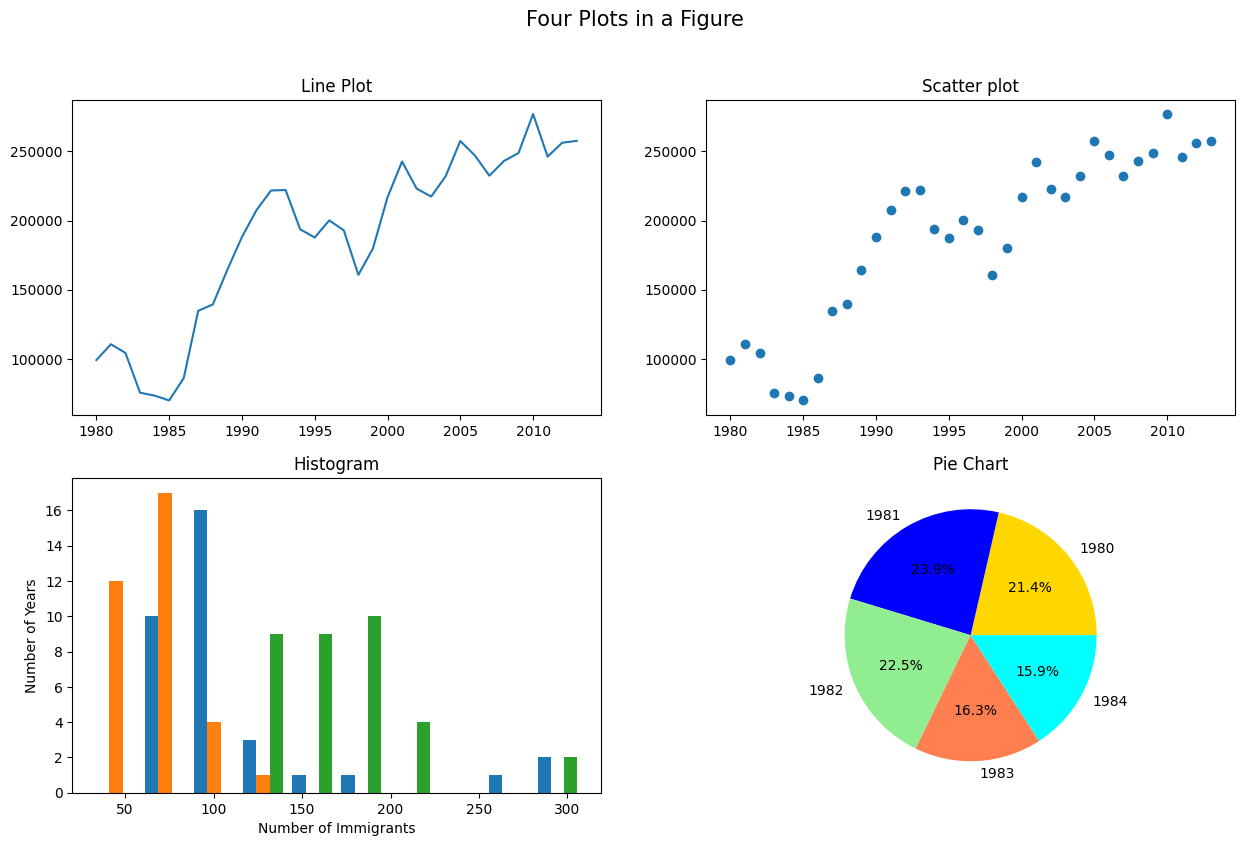

In [105]:
fig= plt.figure(figsize=(15,9))
ax1=fig.add_subplot(2, 2, 1)
ax1.plot(total_immigrants)
ax1.set_title('Line Plot')

ax2=fig.add_subplot(2,2,2)
ax2.scatter(total_immigrants.index, total_immigrants)
ax2.set_title('Scatter plot')

ax3=fig.add_subplot(2,2,3)
ax3.hist(df_dns)
ax3.set_title('Histogram') 
ax3.set_xlabel('Number of Immigrants')
ax3.set_ylabel('Number of Years')

ax4= fig.add_subplot(2,2,4)
ax4.pie(total_immigrants[0:5], labels=years[0:5], 
           colors = ['gold','blue','lightgreen','coral','cyan'],
           autopct='%1.1f%%')
ax4.set_aspect('equal')  
ax4.set_title('Pie Chart')

fig.suptitle('Four Plots in a Figure', fontsize=15)
plt.show()

---

## Waffle Charts, Word Clouds, and Regression Plots

### Objectives

*   Create Word cloud and Waffle charts
*   Create regression plots with Seaborn library


## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">

1.  [Waffle Charts](#3) <br>
4.  [Word Clouds](#4) <br>
5.  [Ploting with Seaborn](#5) <br>
6.  [Regression Plots](#6) <br>
7.  [Author](#author)

</div>

# Waffle Charts <a id="3"></a>

A `waffle chart` is an interesting visualization that is normally created to display progress toward goals. It is commonly an effective option when you are trying to add interesting visualization features to a visual that consists mainly of cells, such as an Excel dashboard.

Unfortunately, unlike R, `waffle` charts are not built into any of the Python visualization libraries. Therefore, I created them from scratch.

In [106]:
from PIL import Image
import matplotlib.patches as mpatches
!pip install -qqq seaborn wordcloud 
import wordcloud


Using the previous case study about Denmark, Norway, and Sweden.
Determing the proportion of each category with respect to the total.

In [107]:
df_dns = df_can.loc[['Denmark', 'Norway', 'Sweden'], :]
total_values = df_dns['Total'].sum()
category_proportions = df_dns['Total'] / total_values
pd.DataFrame({"Category Proportion": category_proportions})

,Category Proportion
Denmark,0.322557
Norway,0.192409
Sweden,0.485034


In [108]:
width = 40 # width of chart
height = 10 # height of chart
total_num_tiles = width * height # total number of tiles

Using the proportion of each category to determe it respective number of tiles

In [109]:
# compute the number of tiles for each category
tiles_per_category = (category_proportions * total_num_tiles).round().astype(int)

pd.DataFrame({"Number of tiles": tiles_per_category})

,Number of tiles
Denmark,129
Norway,77
Sweden,194


Based on the calculated proportions, Denmark will occupy 129 tiles of the `waffle` chart, Norway will occupy 77 tiles, and Sweden will occupy 194 tiles.

Creating a matrix that resembles the `waffle` chart and populating it.


In [110]:
waffle_chart = np.zeros((height, width), dtype = np.uint)

# define indices to loop through waffle chart
category_index = 0
tile_index = 0

# populate the waffle chart
for col in range(width):
    for row in range(height):
        tile_index += 1

        # if the number of tiles populated for the current category is equal to its corresponding allocated tiles
        if tile_index > sum(tiles_per_category[0:category_index]):
            #proceed to the next category
            category_index += 1       
            
        # set the class value to an integer, which increases with class
        waffle_chart[row, col] = category_index
        
print ('Waffle chart populated!')

Waffle chart populated!


In [111]:
waffle_chart

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

As expected, the matrix consists of three categories and the total number of each category's instances matches the total number of tiles allocated to each category.

Maping the `waffle` chart matrix into a visual, prettifying it, and adding legend.

<Figure size 640x480 with 0 Axes>

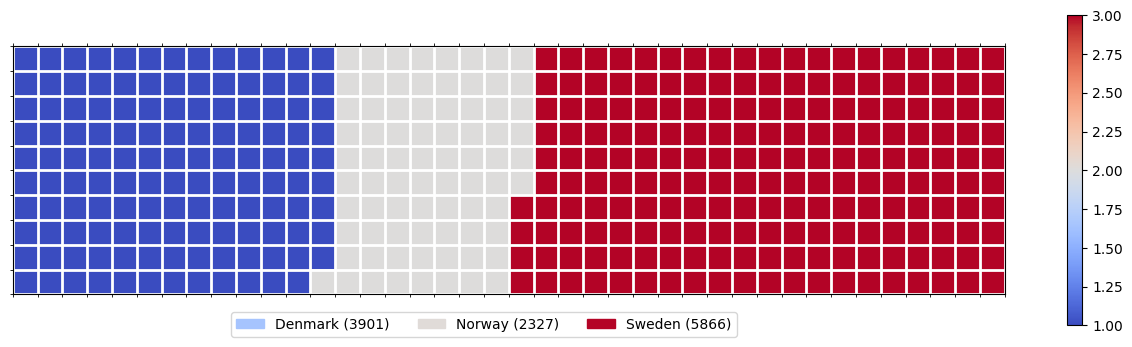

In [112]:
fig = plt.figure()

# use matshow to display the waffle chart
colormap = plt.cm.coolwarm
plt.matshow(waffle_chart, cmap=colormap)
plt.colorbar()

ax = plt.gca()

# set minor ticks
ax.set_xticks(np.arange(-.5, (width), 1), minor=True)
ax.set_yticks(np.arange(-.5, (height), 1), minor=True)
    
# adding gridlines based on minor ticks
ax.grid(which='minor', color='w', linestyle='-', linewidth=2)

plt.xticks([])
plt.yticks([])

# computing cumulative sum of individual categories to match color schemes between chart and legend
values_cumsum = np.cumsum(df_dns['Total'])
total_values = values_cumsum[len(values_cumsum) - 1]

# creating legend
legend_handles = []
for i, category in enumerate(df_dns.index.values):
    label_str = category + ' (' + str(df_dns['Total'][i]) + ')'
    color_val = colormap(float(values_cumsum[i])/total_values)
    legend_handles.append(mpatches.Patch(color=color_val, label=label_str))

# adding legend to chart
plt.legend(handles=legend_handles,
           loc='lower center', 
           ncol=len(df_dns.index.values),
           bbox_to_anchor=(0., -0.2, 0.95, .1)
          )
plt.show();

It is very inefficient to repeat these seven steps every time I want to create a `waffle` chart. Combining everything into one function called *create_waffle_chart*. This function would take the following parameters as input:

> 1.  **categories**: Unique categories or classes in dataframe.
> 2.  **values**: Values corresponding to categories or classes.
> 3.  **height**: Defined height of waffle chart.
> 4.  **width**: Defined width of waffle chart.
> 5.  **colormap**: Colormap class
> 6.  **value_sign**: In order to make my function more generalizable, I added this parameter to address signs that could be associated with a value such as %, $. **value_sign** has a default value of empty string.

In [113]:
def create_waffle_chart(categories, values, height, width, colormap, value_sign=''):

    # compute the proportion of each category with respect to the total
    total_values = sum(values)
    category_proportions = [(float(value) / total_values) for value in values]

    # compute the total number of tiles
    total_num_tiles = width * height # total number of tiles
    print ('Total number of tiles is', total_num_tiles)
    
    # compute the number of tiles for each catagory
    tiles_per_category = [round(proportion * total_num_tiles) for proportion in category_proportions]

    # print out number of tiles per category
    for i, tiles in enumerate(tiles_per_category):
        print (df_dns.index.values[i] + ': ' + str(tiles))
    
    # initialize the waffle chart as an empty matrix
    waffle_chart = np.zeros((height, width))

    # define indices to loop through waffle chart
    category_index = 0
    tile_index = 0

    # populate the waffle chart
    for col in range(width):
        for row in range(height):
            tile_index += 1
            # if the number of tiles populated for the current category 
            # is equal to its corresponding allocated tiles...
            if tile_index > sum(tiles_per_category[0:category_index]):
                # ...proceed to the next category
                category_index += 1       
            
            # set the class value to an integer, which increases with class
            waffle_chart[row, col] = category_index
    
    # instantiate a new figure object
    fig = plt.figure()

    # use matshow to display the waffle chart
    colormap = plt.cm.coolwarm
    plt.matshow(waffle_chart, cmap=colormap)
    plt.colorbar()

    # get the axis
    ax = plt.gca()

    # set minor ticks
    ax.set_xticks(np.arange(-.5, (width), 1), minor=True)
    ax.set_yticks(np.arange(-.5, (height), 1), minor=True)
    
    # add dridlines based on minor ticks
    ax.grid(which='minor', color='w', linestyle='-', linewidth=2)

    plt.xticks([])
    plt.yticks([])

    # compute cumulative sum of individual categories to match color schemes between chart and legend
    values_cumsum = np.cumsum(values)
    total_values = values_cumsum[len(values_cumsum) - 1]

    # create legend
    legend_handles = []
    for i, category in enumerate(categories):
        if value_sign == '%':
            label_str = category + ' (' + str(values[i]) + value_sign + ')'
        else:
            label_str = category + ' (' + value_sign + str(values[i]) + ')'
            
        color_val = colormap(float(values_cumsum[i])/total_values)
        legend_handles.append(mpatches.Patch(color=color_val, label=label_str))

    # add legend to chart
    plt.legend(
        handles=legend_handles,
        loc='lower center', 
        ncol=len(categories),
        bbox_to_anchor=(0., -0.2, 0.95, .1)
    )
    plt.show();

Now to create a `waffle` chart, all I did was call the function `create_waffle_chart`.

Total number of tiles is 400
Denmark: 129
Norway: 77
Sweden: 194


<Figure size 640x480 with 0 Axes>

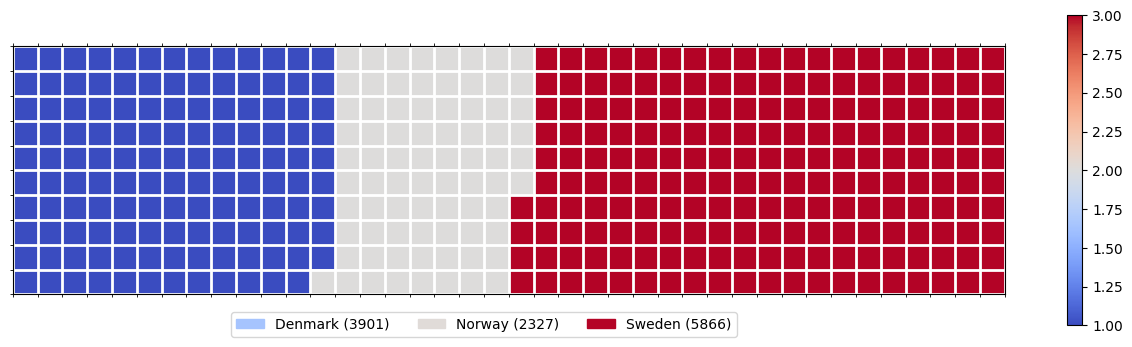

In [114]:
width = 40 # width of chart
height = 10 # height of chart
categories = df_dns.index.values # categories
values = df_dns['Total'] # correponding values of categories
colormap = plt.cm.coolwarm # color map class

create_waffle_chart(categories, values, height, width, colormap);

Creating the same waffle chart with **pywaffle** now


In [115]:
%pip install -qqq pywaffle
%pip install --upgrade -qqq pywaffle
from pywaffle import Waffle

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


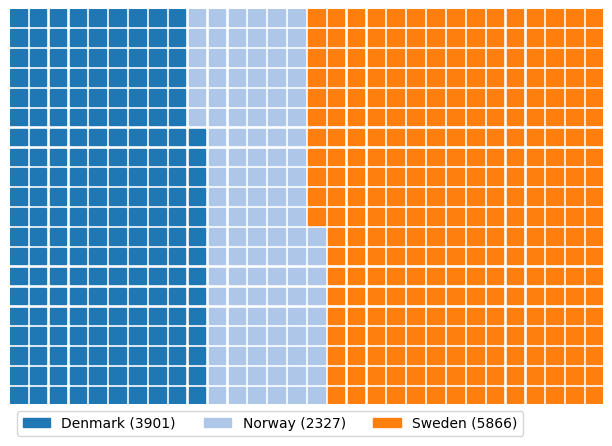

In [117]:
fig = plt.figure(FigureClass = Waffle,
                 rows = 20, columns = 30, #pass the number of rows and columns for the waffle 
                 values = df_dns['Total'], #pass the data to be used for display
                 cmap_name = 'tab20', #color scheme
                 legend = {'labels': [f"{k} ({v})" for k, v in zip(df_dns.index.values,df_dns.Total)],
                            'loc': 'lower left', 'bbox_to_anchor':(0,-0.1),'ncol': 3}
                )
plt.show();

Creating a Waffle chart to dispaly the proportiona of China and Inida total immigrant contribution.

In [120]:
df_ci = df_can.loc[['China', 'India'], :]

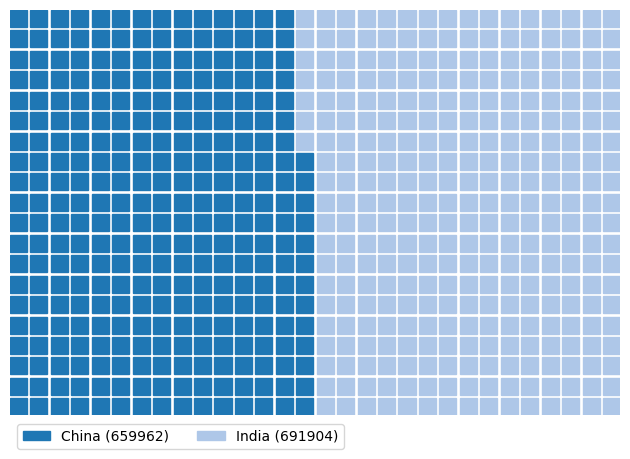

In [121]:
fig = plt.figure(FigureClass = Waffle,
                     rows = 20, columns = 30,
                     values = df_ci["Total"], 
                     cmap_name = 'tab20', 
                     legend = {'labels':[f"{k} ({v})" for k, v in zip(df_ci.index.values,df_ci.Total)],
                                'loc': 'lower left', 'bbox_to_anchor':(0,-0.1),'ncol': 2}
                    )

plt.show();

---

# Word Clouds <a id="4"></a>

`Word` clouds work in a simple way: the more a specific word appears in a source of textual data (such as a speech, blog post, or database), the bigger and bolder it appears in the word cloud.

The package, called `word_cloud` was developed by **Andreas Mueller**.

In [122]:
from wordcloud import WordCloud, STOPWORDS

`Word` clouds are commonly used to perform high-level analysis and visualization of text data. Accordinly, I worked with an example that involves analyzing text data. 

Analyzing a short novel written by **Lewis Carroll** titled *Alice's Adventures in Wonderland*. Downloading a *.txt* file of the novel.

In [123]:
import urllib

# open the file and read it into a variable
alice_novel = urllib.request.urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/alice_novel.txt').read().decode("utf-8")

Using the stopwords that I imported from `word_cloud`. Using the function *set* to remove any redundant stopwords.


In [134]:
stopwords = set(STOPWORDS)

Creating a word cloud object and generating a word cloud. For simplicity, I generated a word cloud using only the first 2000 words in the novel.

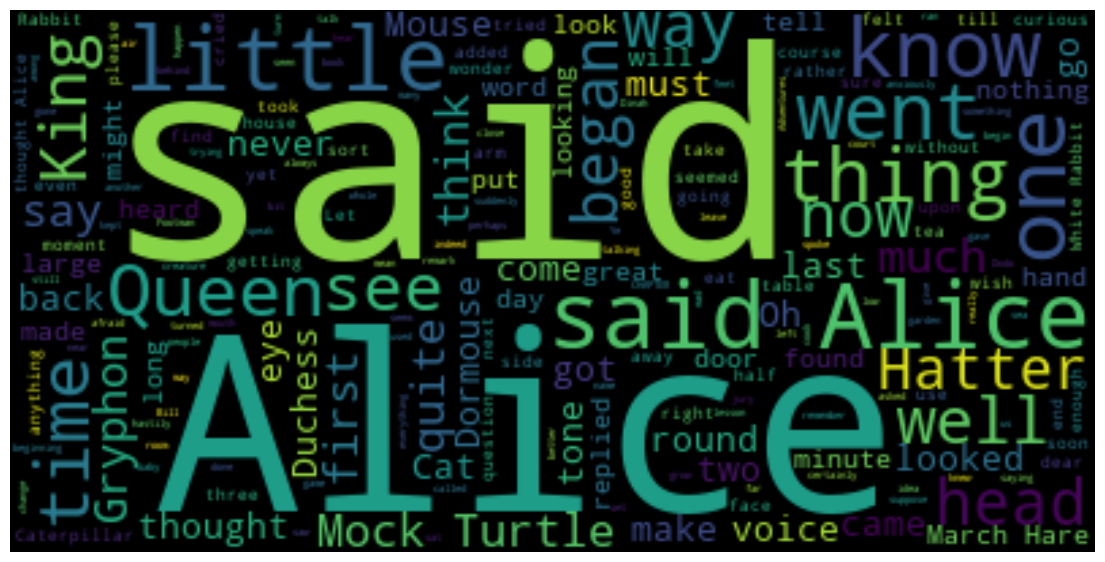

In [135]:
# instantiate a word cloud object
alice_wc = WordCloud(stopwords= stopwords)

# generate the word cloud
alice_wc.generate(alice_novel)

fig = plt.figure(figsize=(14, 18))
plt.imshow(alice_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

So in the first 2000 words in the novel, the most common words are **Alice**, **said**, **little**, **Queen**, and so on.

However, **said** isn't really an informative word. So I added it to the stopwords and re-generated the cloud.

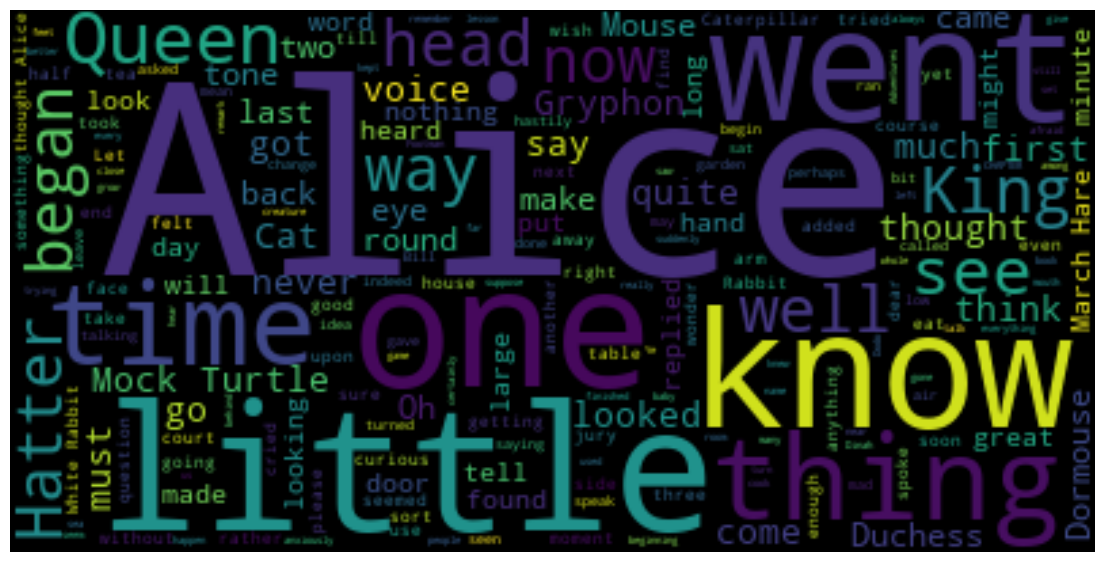

In [136]:
stopwords.add('said') # add the words said to stopwords

alice_wc.generate(alice_novel)
fig = plt.figure(figsize=(14, 18))

plt.imshow(alice_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

This looks really interesting! Another cool thing I implemented with the `word_cloud` package is superimposing the words onto a mask of any shape.

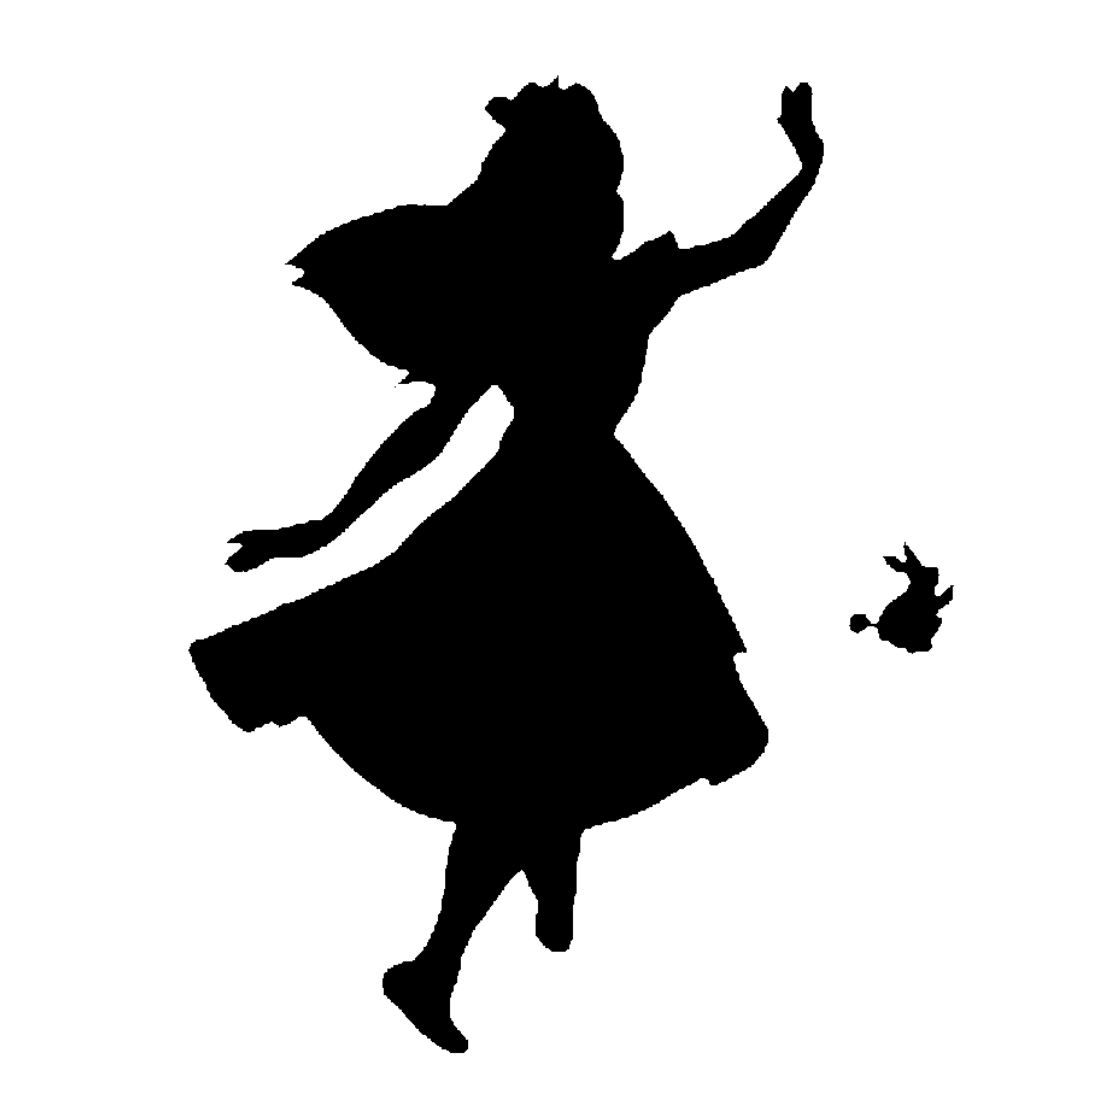

In [137]:
alice_mask = np.array(Image.open(urllib.request.urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/Module%204/images/alice_mask.png')))
fig = plt.figure(figsize=(14, 18))

plt.imshow(alice_mask, cmap=plt.cm.gray, interpolation='bilinear')
plt.axis('off')
plt.show()

Shaping the `word` cloud according to the mask is straightforward using `word_cloud` package. For simplicity, I continued using the first 2000 words in the novel.

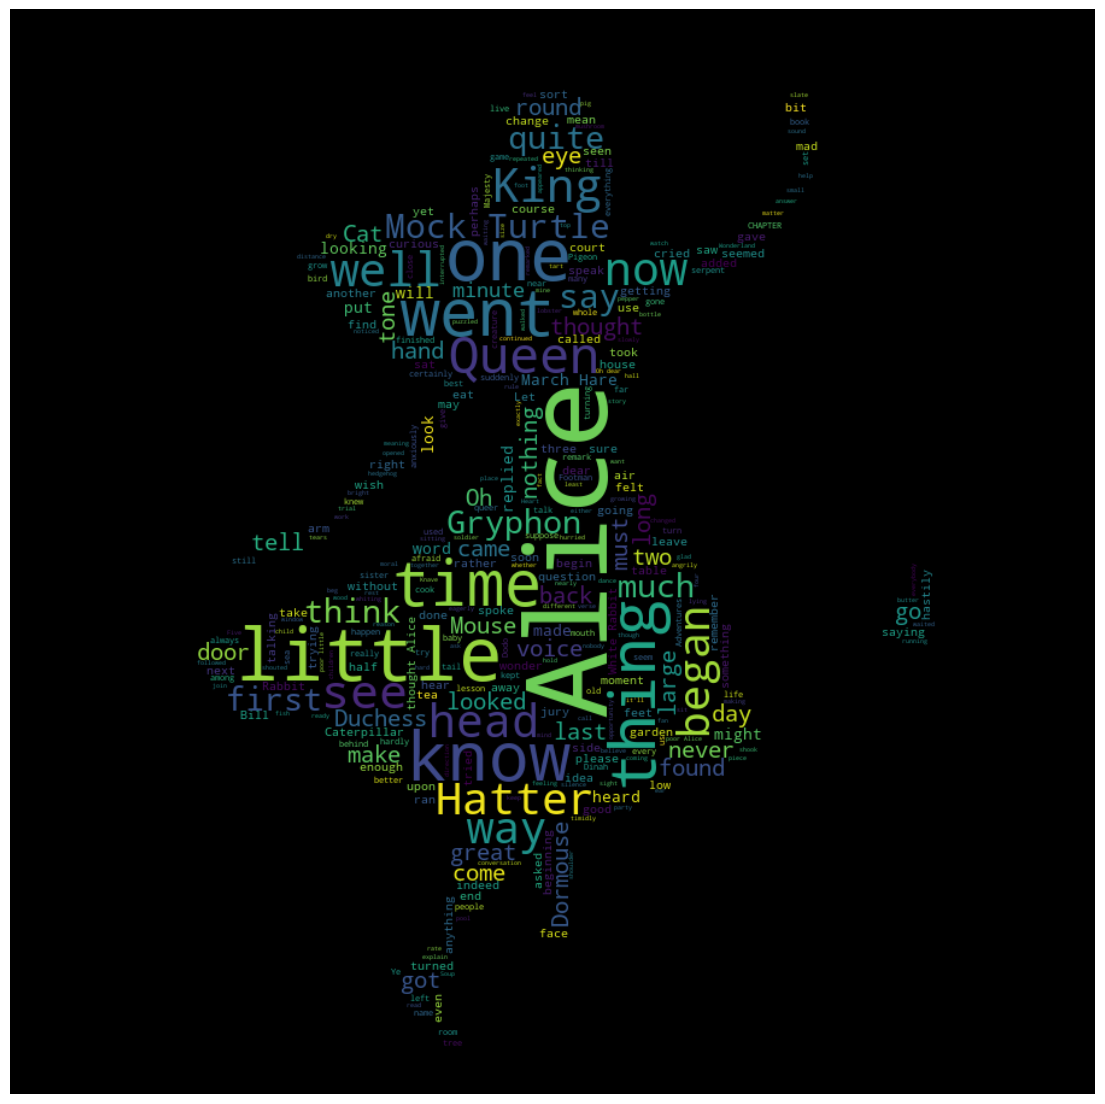

In [139]:
alice_wc = WordCloud(background_color='black', max_words=2000, mask=alice_mask, stopwords=stopwords)

# generate the word cloud
alice_wc.generate(alice_novel)

# display the word cloud
fig = plt.figure(figsize=(14, 18))

plt.imshow(alice_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

The immigration data does not have any text data.

Generating sample text data from our immigration dataset, say text data of 90 words.

In [140]:
total_immigration = df_can['Total'].sum()
total_immigration

np.int64(6409153)

Using countries with single-word names, I duplicated each country's name based on how much they contribute to the total immigration.

In [141]:
max_words = 90
word_string = ''
for country in df_can.index.values:
    if country.count(" ") == 0:
        repeat_num_times = int(df_can.loc[country, 'Total'] / total_immigration * max_words)
        word_string = word_string + ((country + ' ') * repeat_num_times)

word_string

'Colombia Morocco Egypt Portugal Guyana Haiti Romania Jamaica France Lebanon Poland Pakistan Pakistan Pakistan Philippines Philippines Philippines Philippines Philippines Philippines Philippines China China China China China China China China China India India India India India India India India India '

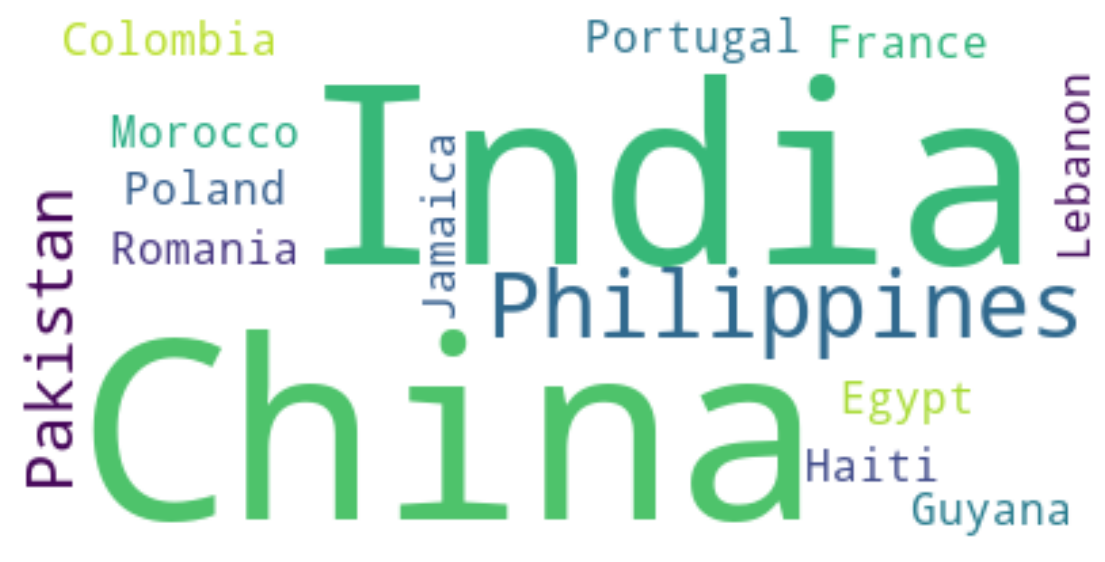

In [142]:
wordcloud = WordCloud(background_color='white').generate(word_string)
plt.figure(figsize=(14, 18))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

According to the above word cloud, the majority of the people who immigrated came from one of 15 countries that are displayed by the word cloud. 

---

# Plotting with Seaborn <a id="5"></a>

Seaborn is a Python visualization library based on matplotlib. It provides a high-level interface for drawing attractive statistical graphics.

In [143]:
df_can['Continent'].unique()

array(['Oceania', 'Africa', 'Europe', 'Northern America', 'Asia',
       'Latin America and the Caribbean'], dtype=object)

<Axes: xlabel='Continent', ylabel='count'>

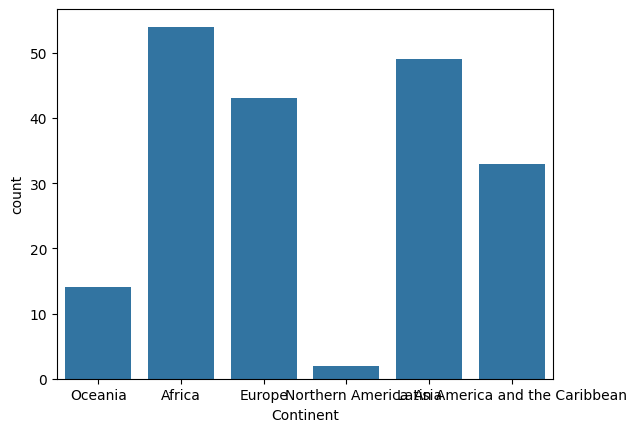

In [144]:
sns.countplot(x='Continent', data=df_can)

The labels on the x-axis does not look as expected.

Replacing the 'Latin America and the Caribbean' with and "L-America", 'Northern America' with "N-America", and changing the figure size

<Axes: xlabel='Continent', ylabel='count'>

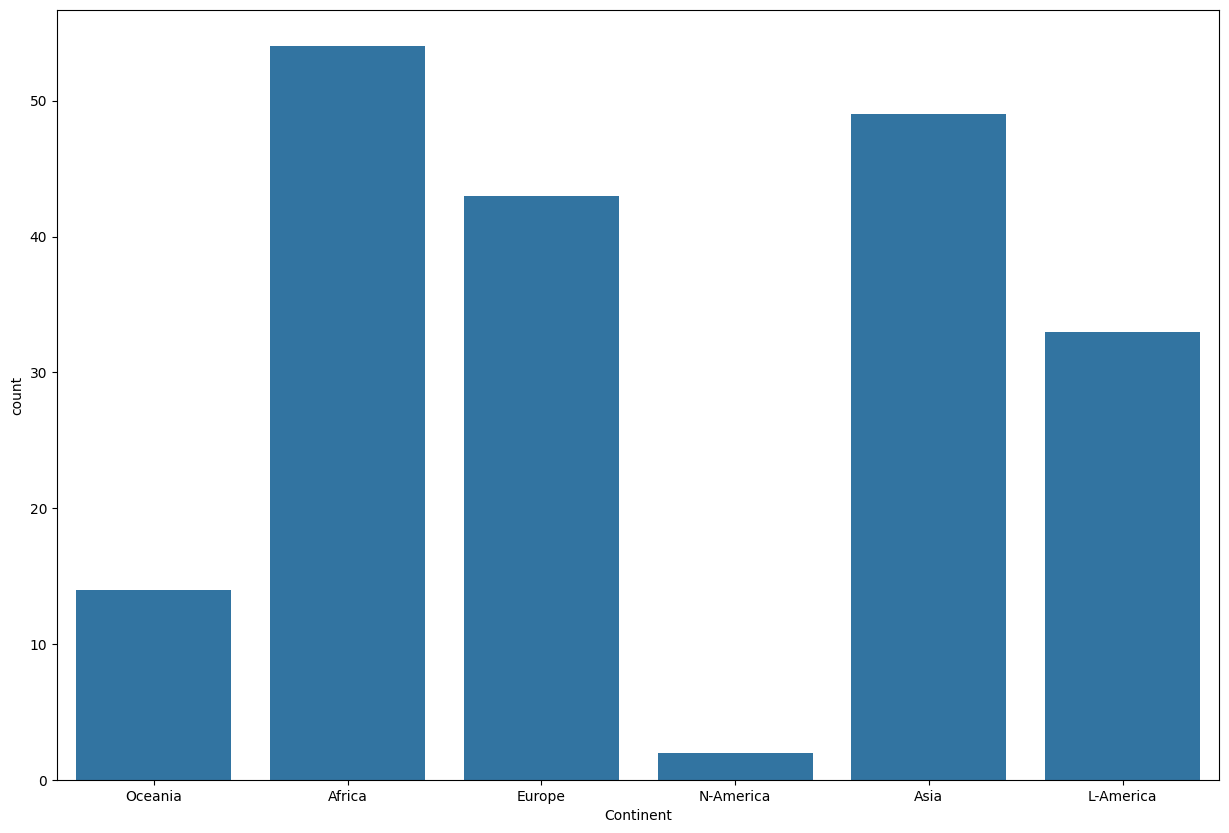

In [145]:
df_can1 = df_can.replace('Latin America and the Caribbean', 'L-America')
df_can1 = df_can1.replace('Northern America', 'N-America')
plt.figure(figsize=(15, 10))
sns.countplot(x='Continent', data=df_can1)

### Barplot

This plot will perform the Groupby on a categorical varaible and plot aggregated values, with confidence intervals

Ploting the total immigrants Continent-wise

<Axes: xlabel='Continent', ylabel='Total'>

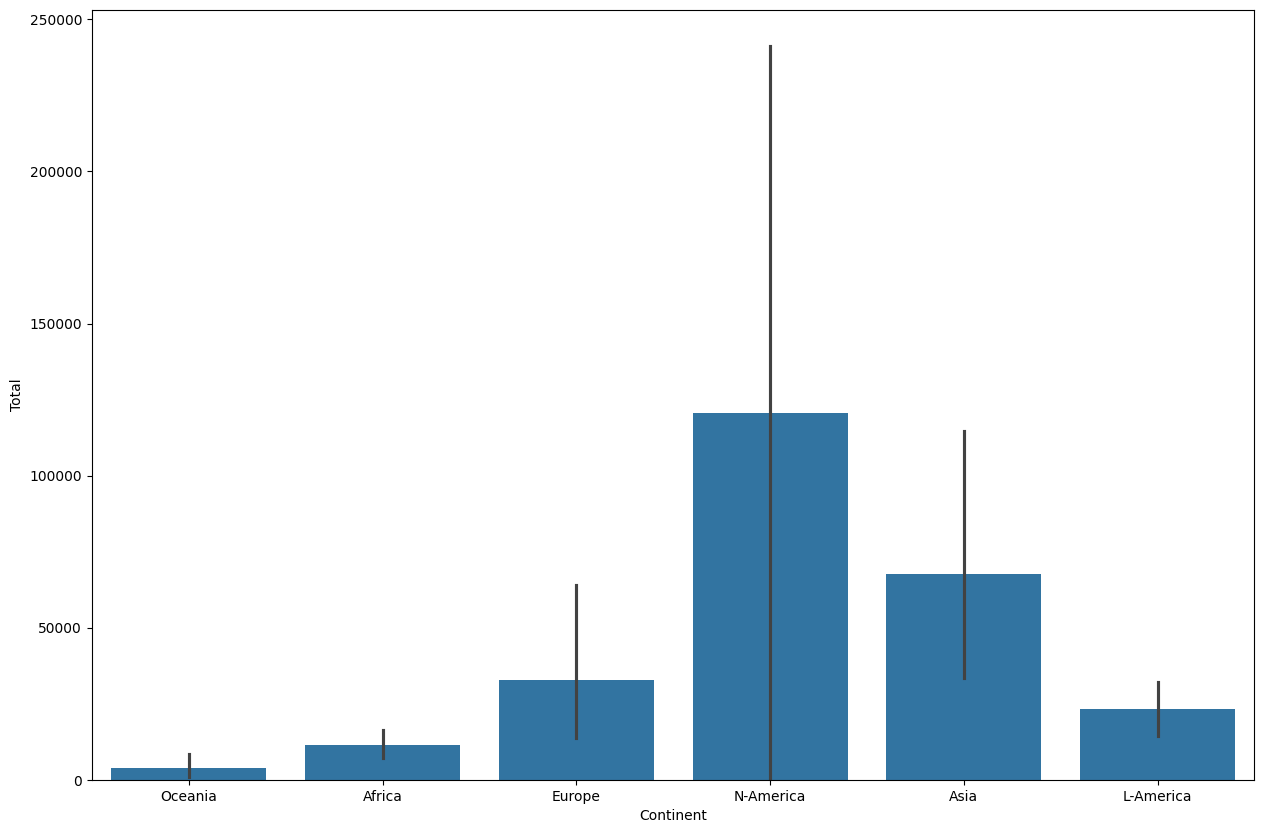

In [146]:
plt.figure(figsize=(15, 10))
sns.barplot(x='Continent', y='Total', data=df_can1)

Verifing the values by performing the groupby on the Total and Continent for mean()

In [147]:
df_Can2=df_can1.groupby('Continent')['Total'].mean()
df_Can2

Continent
Africa        11462.000000
Asia          67710.081633
Europe        32812.720930
L-America     23186.303030
N-America    120571.000000
Oceania        3941.000000
Name: Total, dtype: float64

## Regression Plot <a id="6"></a>

With *seaborn*, generating a regression plot is as simple as calling the **regplot** function.

In [148]:
df_tot = pd.DataFrame(df_can[years].sum(axis=0))

# change the years to type float (useful for regression later on)
df_tot.index = map(float, df_tot.index)

# reset the index to put in back in as a column in the df_tot dataframe
df_tot.reset_index(inplace=True)

# rename columns
df_tot.columns = ['year', 'total']

df_tot.head()

,year,total
0,1980.0,99137
1,1981.0,110563
2,1982.0,104271
3,1983.0,75550
4,1984.0,73417


<Axes: xlabel='year', ylabel='total'>

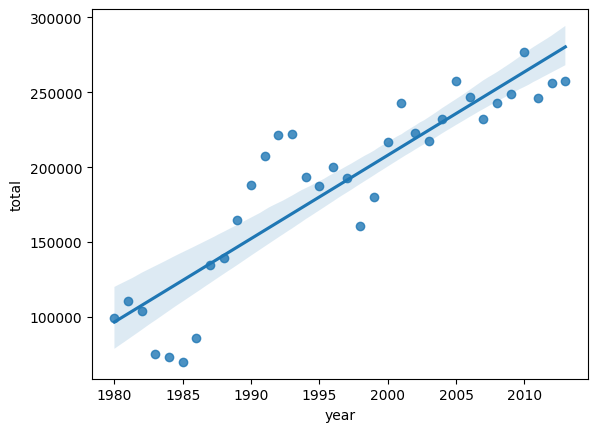

In [149]:
sns.regplot(x='year', y='total', data=df_tot)

Customizing the marker shape, so instead of circular markers, using `+`. Blowing up the plot a little so that it is more appealing to the sight. Also, increasing the size of markers so they match the new size of the figure, and adding a title and x- and y-labels.

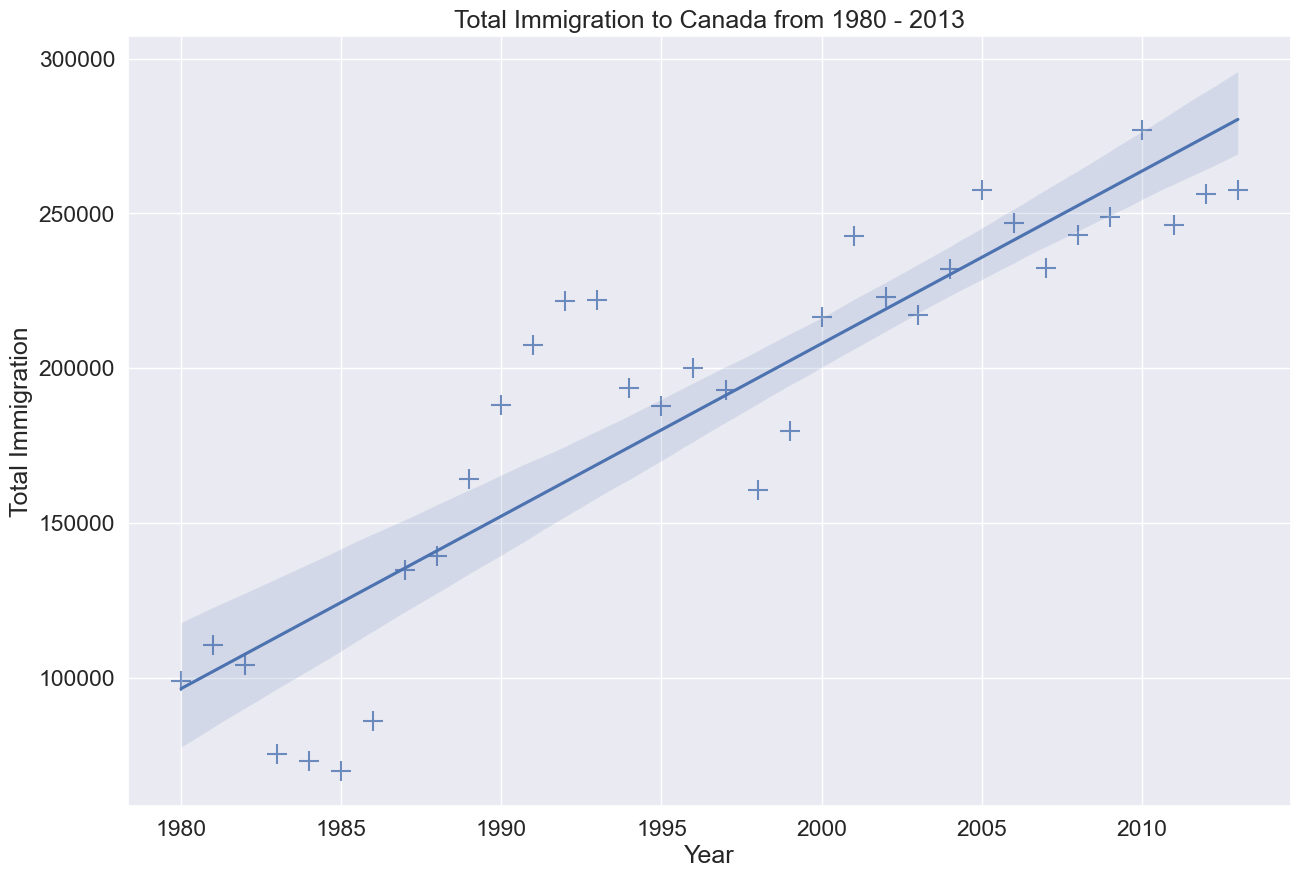

In [155]:
plt.figure(figsize=(15, 10))
sns.set(font_scale=1.5)

ax = sns.regplot(x='year', y='total', data=df_tot, marker='+', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigration to Canada from 1980 - 2013')
plt.show()

Using seaborn to create a scatter plot with a regression line to visualize the total immigration from Denmark, Sweden, and Norway to Canada from 1980 to 2013.

Text(0.5, 1.0, 'Total Immigrationn from Denmark, Sweden, and Norway to Canada from 1980 - 2013')

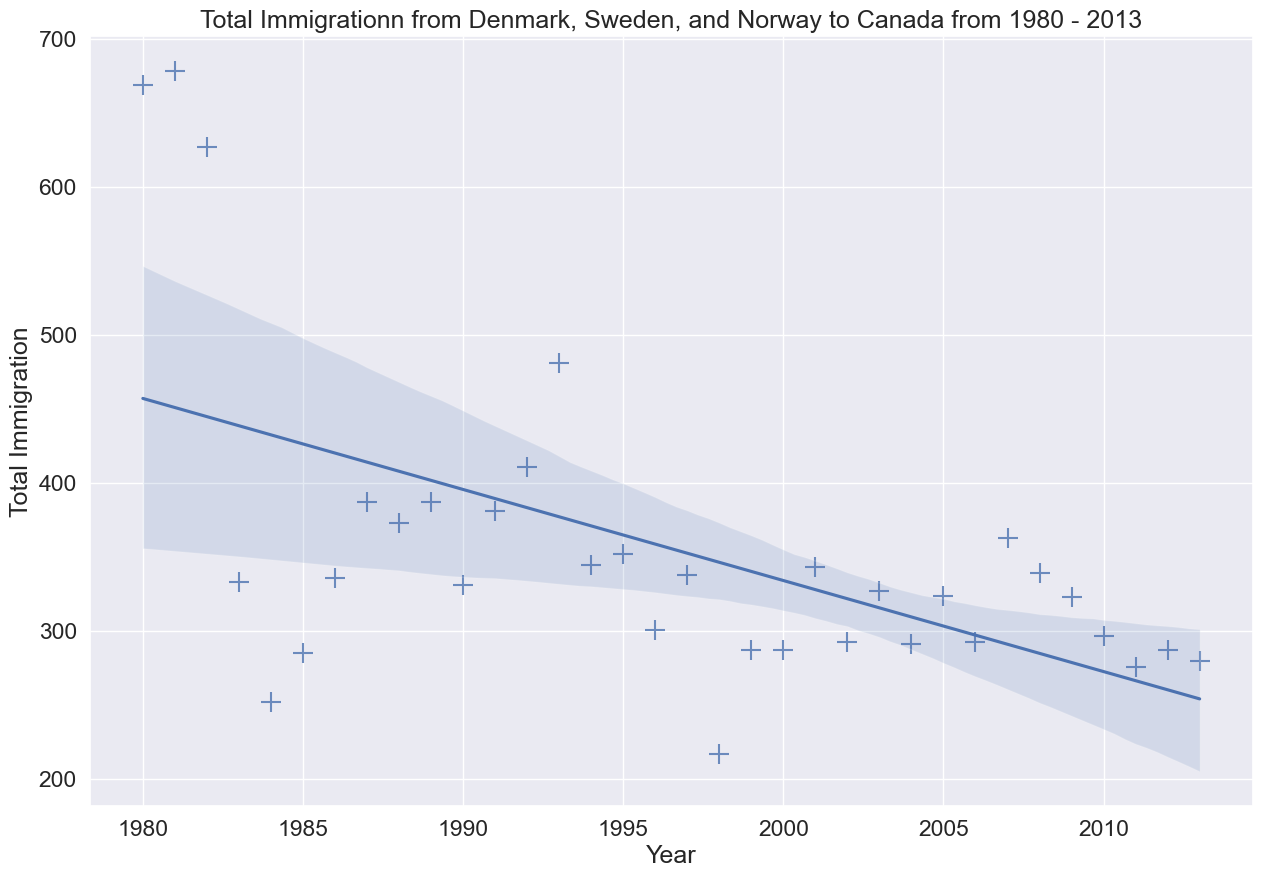

In [158]:
df_countries = df_can.loc[['Denmark', 'Norway', 'Sweden'], years].transpose()

# create df_total by summing across three countries for each year
df_total = pd.DataFrame(df_countries.sum(axis=1))

# reset index in place
df_total.reset_index(inplace=True)

# rename columns
df_total.columns = ['year', 'total']

# change column year from string to int to create scatter plot
df_total['year'] = df_total['year'].astype(int)

# define figure size
plt.figure(figsize=(15, 10))

# define background style and font size
sns.set(font_scale=1.5)

# generate plot and add title and axes labels
ax = sns.regplot(x='year', y='total', data=df_total, marker='+', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigrationn from Denmark, Sweden, and Norway to Canada from 1980 - 2013')

---

<div class="alert alert-block alert-info" style="margin-top: 20px">

## Author <a id="author"></a>
- [Parshv Patel](#https://www.linkedin.com/in/parshv-patel-65a90326b/)
</div>
